## Example of Using TCA (One-Dimensional)

This section illustrates a complete pipeline using the `trajectoryclusteringanalysis` package on a one-dimensional dataset, referred to here as `unidimensional_data`.

This dataset tracks the longitudinal clinical progression of patients diagnosed with a chronic condition over several months. The primary variable of interest is **`care_status`**, which captures the patient’s position in the care cascade at a given month ($t$):
* **`D` (Diagnosed)**: Diagnosed, but not currently engaged in care.
* **`C` (Care)**: Engaged in care (followed in a clinic), but not yet on treatment.
* **`T` (Treatment)**: On treatment, but the infection is not yet controlled/suppressed.
* **`S` (Suppressed/Success)**: On treatment with the infection successfully controlled.

For each patient, the following socio-demographic and geographic covariates are available:
* **`age`**: Age group (1: Young, 2: Adult, 3: Senior).
* **`sex`**: 0 for Male, 1 for Female.
* **`education`**: Level of education (1: Primary, 2: Secondary, 3: Higher).
* **`wealth`**: Wealth index based on an asset score (1: Poor, 2: Moderate, 3: Rich).
* **`distance_clinic`**: Geographic proximity to the nearest healthcare center (1: Close, 2: Far).

> **Objective**: To cluster patients with similar care trajectories.

### Workflow

1. **Initialization**: Import the necessary libraries, functions, and the dataset.
2. **Preprocessing**: Prepare the dataset and initialize the TCA environment.
3. **Distance Computation**: Calculate the `distance_matrix` using metrics appropriate for sequential data (e.g., Hamming, Levenshtein, Optimal Matching).
4. **Clustering**: Apply partitioning or hierarchical algorithms (e.g., HAC, K-means, K-medoids) based on the computed distance matrix.
5. **Downstream Analysis**: Implement extensions to analyze the relationship between the resulting clusters and the patient covariates.

> **Note**: In this specific case study, missing values (`NaN`) are not treated as a distinct clinical state.

# 1. Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.ajouts import *

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


In [2]:
df = pd.read_csv(project_root / "data" / "unidimensional_data.csv")

# Keep only patients with at least 19 observations (months 0 to 18)
seq_length = df.groupby('id')['month'].count()
ids_to_keep = seq_length[seq_length >= 19].index
df = df[df['id'].isin(ids_to_keep)].copy()

# Restrict to the first 18 months
df = df[df['month'] <= 18].copy()
df = df.reset_index(drop=True)

print(f"Number of patients after filtering: {df['id'].nunique()}")
df.head()

Number of patients after filtering: 1317


,id,month,care_status,sex,age,education,wealth,distance_clinic
0,15,0.0,D,1.0,2.0,1.0,3.0,2.0
1,15,1.0,D,1.0,2.0,1.0,3.0,2.0
2,15,2.0,D,1.0,2.0,1.0,3.0,2.0
3,15,3.0,D,1.0,2.0,1.0,3.0,2.0
4,15,4.0,T,1.0,2.0,1.0,3.0,2.0


# 2. Preparing the Dataset and Initializing the TCA

We transform the data to obtain a person-month matrix. This format retains only the temporal trend, eliminating other variables to simplify the analysis.

In [3]:
stats_columns = ['sex', 'age', 'education', 'wealth', 'distance_clinic']

wide_df, col_stats = long_to_wide_format(df, id_col="id", time_col="month", value_col="care_status", prefix="month_", static_cols = stats_columns, shift_time=True, sample_frac=1, random_state=42)

label_var = {
    'sex': {0.0: 'Male', 1.0: 'Female'},
    'distance_clinic': {1.0: 'Close', 2.0: 'Far'},
    'wealth': {1.0: 'Poor', 2.0: 'Moderate', 3.0: 'Rich'},
    'education': {1.0: 'Primary', 2.0: 'Secondary', 3.0: 'Higher'},
    'age': {1.0: '16-29', 2.0: '30-59', 3.0: '60+'}
}

wide_df.head()

,id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19
0,15,D,D,D,D,T,T,T,C,D,D,D,D,D,D,D,C,C,C,C
1,18,D,D,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S
2,43,D,D,D,D,C,T,T,S,S,S,S,S,S,S,S,S,S,S,S
3,48,C,T,T,T,T,T,C,C,C,T,T,T,C,C,C,T,T,T,C
4,53,D,D,D,D,D,D,D,S,S,S,S,S,S,S,S,S,S,S,S


We can now create an instance of TCA for one-dimensional analysis:

In [4]:
tca = TCA(data=wide_df,
              index_col='id',
              time_col=None,  # Not used in one-dimensional analysis
              event_col=None,  # Not used in one-dimensional analysis
              alphabet=['D', 'C', 'T', 'S'],
              states=["diagnosed", "under care", "under treatment", "controlled"], 
              mode='unidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The unidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (1317, 20)
state coding:
   alphabet            label  label encoded
0        D        diagnosed              1
1        C       under care              2
2        T  under treatment              3
3        S       controlled              4


# 3. Calculating Distances

First, we calculate our cost matrices

In [5]:
# Method 1: Constant-Cost Matrix
cost_matrix_constant = tca.compute_substitution_cost_matrix()
cost_matrix_constant

,D,C,T,S
D,0.0,2.0,2.0,2.0
C,2.0,0.0,2.0,2.0
T,2.0,2.0,0.0,2.0
S,2.0,2.0,2.0,0.0


In [6]:
#Method 2: Cost Matrix Based on Observation Frequencies
cost_matrix_frequency = tca.compute_substitution_cost_matrix(method='frequency')
cost_matrix_frequency

,D,C,T,S
D,0.000000,1.859677,1.972474,1.985086
C,1.859677,0.000000,1.865922,1.955313
T,1.972474,1.865922,0.000000,1.811693
S,1.985086,1.955313,1.811693,0.000000


In [7]:
# Method 3: Custom Cost Matrix
couts = {
    'D:D': 0.0, 'D:C': 1.0, 'D:T': 2.0, 'D:S': 3.0,
    'C:D': 1.0, 'C:C': 0.0, 'C:T': 1.0, 'C:S': 2.0,
    'T:D': 2.0, 'T:C': 1.0, 'T:T': 0.0, 'T:S': 1.0,
    'S:D': 3.0, 'S:C': 2.0, 'S:T': 1.0, 'S:S': 0.0
}
cost_matrix_custom = tca.compute_substitution_cost_matrix(method='custom', custom_costs=couts)
cost_matrix_custom

,D,C,T,S
D,0.0,1.0,2.0,3.0
C,1.0,0.0,1.0,2.0
T,2.0,1.0,0.0,1.0
S,3.0,2.0,1.0,0.0


These cost matrices can be visualized as a heat map: the closer the color is to red, the higher the cost; the closer it is to yellow, the lower the cost.

Displaying Heatmaps:


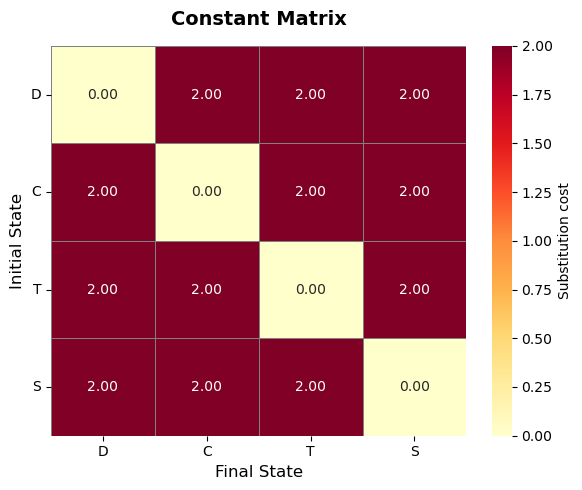

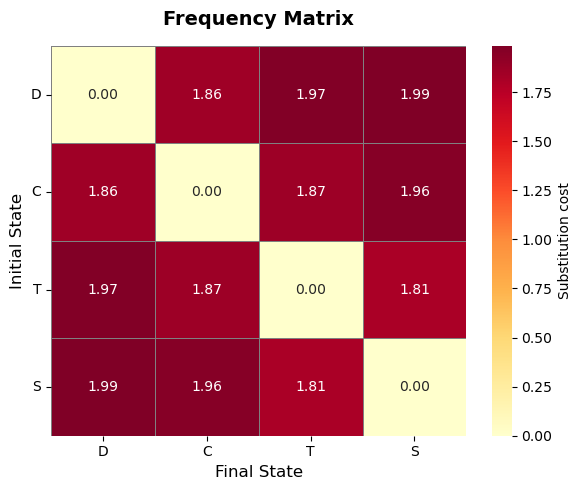

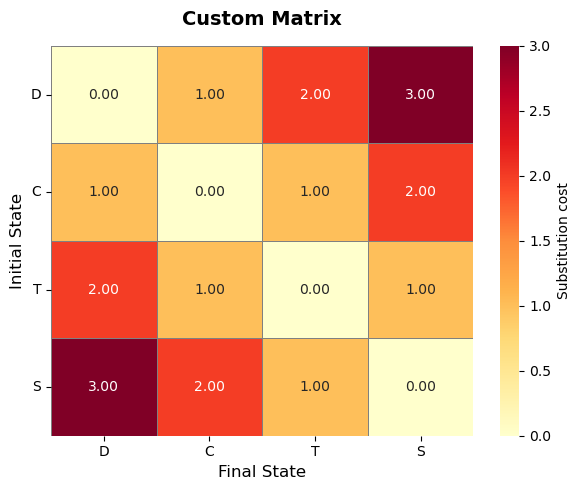

<Axes: title={'center': 'Custom Matrix'}, xlabel='Final State', ylabel='Initial State'>

In [8]:
print("Displaying Heatmaps:")
plot_cost_matrix(cost_matrix_constant, title="Constant Matrix")
plot_cost_matrix(cost_matrix_frequency, title="Frequency Matrix")
plot_cost_matrix(cost_matrix_custom, title="Custom Matrix")

## 3.1. Hamming Distance

In [9]:
distance_matrix_ham = tca.compute_distance_matrix(tca.data,metric='hamming', substitution_cost_matrix=cost_matrix_custom)
print("Distance matrix (Hamming):\n",distance_matrix_ham)

INFO:root:Calculating distance matrix using metric: hamming...
INFO:root:Time taken for computation: 0.06 seconds


Distance matrix (Hamming):
 [[0.         0.89473684 0.68421053 ... 0.78947368 0.94736842 0.73684211]
 [0.89473684 0.         0.26315789 ... 0.57894737 0.52631579 0.21052632]
 [0.68421053 0.26315789 0.         ... 0.47368421 0.47368421 0.15789474]
 ...
 [0.78947368 0.57894737 0.47368421 ... 0.         0.26315789 0.47368421]
 [0.94736842 0.52631579 0.47368421 ... 0.26315789 0.         0.47368421]
 [0.73684211 0.21052632 0.15789474 ... 0.47368421 0.47368421 0.        ]]


## 3.2. Levenshtein Distance

In [10]:
distance_matrix_lev = tca.compute_distance_matrix(tca.data,metric='levenshtein', substitution_cost_matrix=cost_matrix_custom)
print("Distance matrix (Levenshtein):\n",distance_matrix_lev)

INFO:root:Calculating distance matrix using metric: levenshtein...
100%|██████████| 1317/1317 [00:14<00:00, 89.29it/s] 
INFO:root:Time taken for computation: 14.76 seconds


Distance matrix (Levenshtein):
 [[ 0. 17. 13. ... 15. 18. 14.]
 [17.  0.  5. ... 11. 10.  4.]
 [13.  5.  0. ...  9.  9.  2.]
 ...
 [15. 11.  9. ...  0.  5.  9.]
 [18. 10.  9. ...  5.  0.  9.]
 [14.  4.  2. ...  9.  9.  0.]]


## 3.3. Optimal Matching Distance

In [11]:
distance_matrix_OM = tca.compute_distance_matrix(tca.data,metric='optimal_matching', substitution_cost_matrix=cost_matrix_custom)
print("Distance matrix (Optimal Matching):\n",distance_matrix_OM)

INFO:root:Calculating distance matrix using metric: optimal_matching...


Calculated indel cost: 1.5 (from max sub_cost: 3.0)
substitution cost matrix: 
      D    C    T    S
D  0.0  1.0  2.0  3.0
C  1.0  0.0  1.0  2.0
T  2.0  1.0  0.0  1.0
S  3.0  2.0  1.0  0.0


100%|██████████| 1317/1317 [00:03<00:00, 415.56it/s]
INFO:root:Time taken for computation: 3.20 seconds


Distance matrix (Optimal Matching):
 [[0.         2.10526316 1.68421053 ... 1.57894737 1.73684211 1.73684211]
 [2.10526316 0.         0.52631579 ... 0.63157895 0.78947368 0.36842105]
 [1.68421053 0.52631579 0.         ... 0.52631579 0.47368421 0.15789474]
 ...
 [1.57894737 0.63157895 0.52631579 ... 0.         0.26315789 0.47368421]
 [1.73684211 0.78947368 0.47368421 ... 0.26315789 0.         0.52631579]
 [1.73684211 0.36842105 0.15789474 ... 0.47368421 0.52631579 0.        ]]


## 3.4. Dynamic Time Warping (DTW) Distance

In [12]:
distance_matrix_dtw = tca.compute_distance_matrix(tca.data,metric='dtw')
print("Distance matrix (DTW):\n",distance_matrix_dtw)

INFO:root:Calculating distance matrix using metric: dtw...
100%|██████████| 1317/1317 [03:38<00:00,  6.04it/s]
INFO:root:Time taken for computation: 218.08 seconds


Distance matrix (DTW):
 [[0.         0.47368421 0.40768246 ... 0.36082393 0.35696474 0.42105263]
 [0.47368421 0.         0.09116057 ... 0.1745592  0.16643567 0.09116057]
 [0.40768246 0.09116057 0.         ... 0.         0.         0.        ]
 ...
 [0.36082393 0.1745592  0.         ... 0.         0.         0.        ]
 [0.35696474 0.16643567 0.         ... 0.         0.         0.        ]
 [0.42105263 0.09116057 0.         ... 0.         0.         0.        ]]


## 3.5. Global Alignment Kernel (GAK) Distance 

In [13]:
distance_matrix_gak = tca.compute_distance_matrix(tca.data,metric='gak')
print("Distance matrix (GAK):\n",distance_matrix_gak)

INFO:root:Calculating distance matrix using metric: gak...
100%|██████████| 1317/1317 [05:56<00:00,  3.69it/s]
INFO:root:Time taken for computation: 356.75 seconds


Distance matrix (GAK):
 [[0.00000000e+00 3.19412802e-31 5.00425398e-24 ... 8.31693693e-22
  2.73041506e-19 5.64809256e-26]
 [3.19412802e-31 0.00000000e+00 9.60249896e-04 ... 2.10761751e-07
  1.25742497e-07 1.94893775e-03]
 [5.00425398e-24 9.60249896e-04 0.00000000e+00 ... 1.62059280e-04
  5.11789651e-04 4.52535514e-02]
 ...
 [8.31693693e-22 2.10761751e-07 1.62059280e-04 ... 0.00000000e+00
  3.83686324e-03 2.32438302e-04]
 [2.73041506e-19 1.25742497e-07 5.11789651e-04 ... 3.83686324e-03
  0.00000000e+00 5.79915165e-04]
 [5.64809256e-26 1.94893775e-03 4.52535514e-02 ... 2.32438302e-04
  5.79915165e-04 0.00000000e+00]]


# 4. Clustering

## 4.1. Hamming Distance

### 4.1.1. HAC
First, we perform Hierarchical Ascending Clustering to determine the optimal number of clusters

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


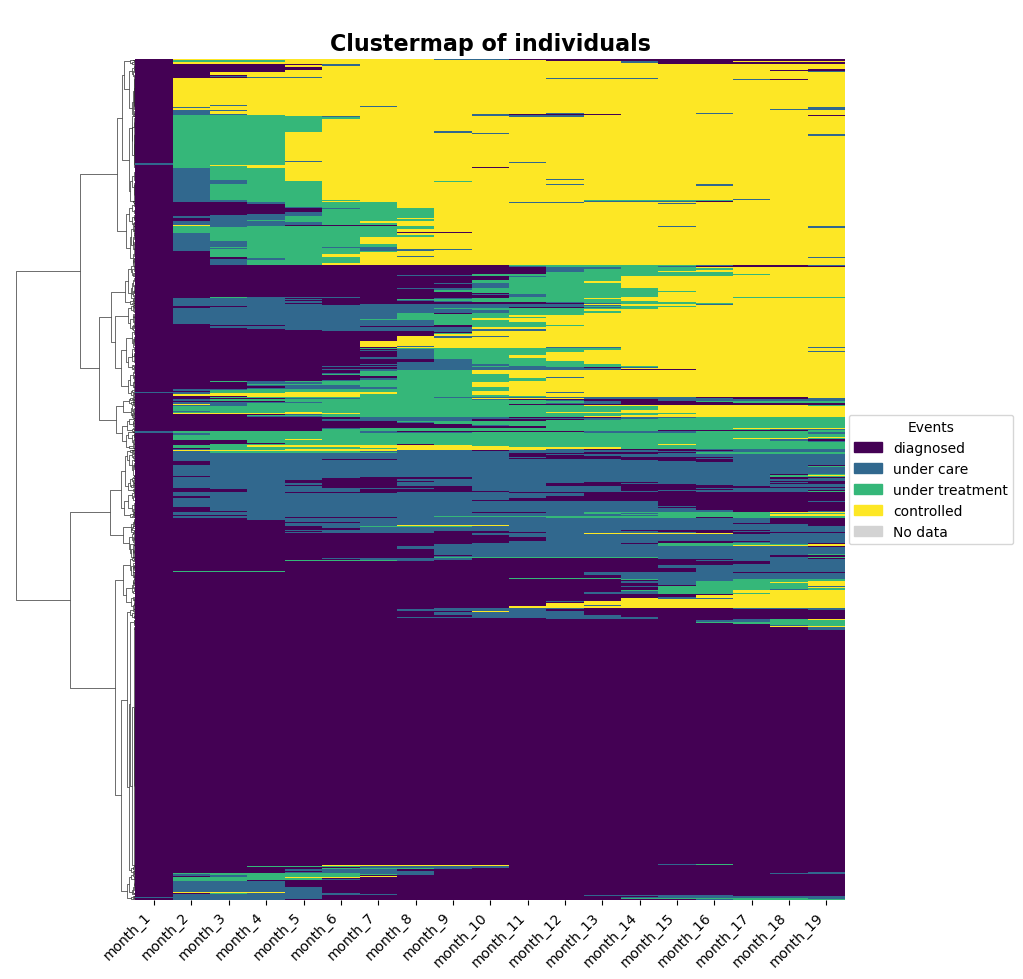

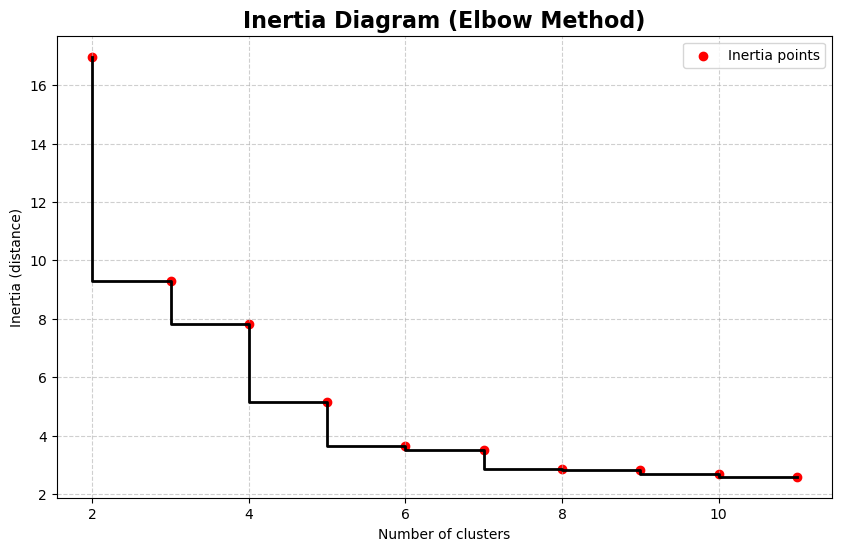

In [14]:
# HCA (Hierarchical Ascending Classification)
linkage_matrix_ham = tca.hierarchical_clustering(distance_matrix_ham)
tca.plot_clustermap(tca.data,linkage_matrix_ham)
tca.plot_inertia(linkage_matrix_ham)

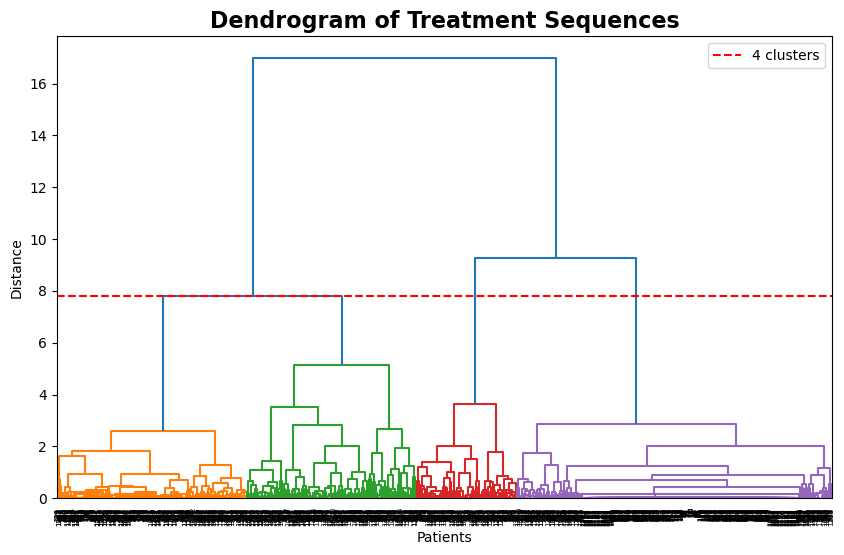

In [15]:
tca.plot_dendrogram(linkage_matrix_ham, n_clusters=4)

### 4.1.2. K-medoids

In [16]:
kmedoids_labels_ham, medoid_indices_ham, inertia_med_ham = tca.kmedoids_clustering(distance_matrix_ham, num_clusters=4,method='fasterpam')
print("kmedoids_labels (Hamming) :", np.unique(kmedoids_labels_ham))
print("medoid_indices (Hamming) :", medoid_indices_ham)
print("inertia (Hamming) :", inertia_med_ham)

INFO:root:Performing K-Medoids clustering with 4 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Hamming) : [1 2 3 4]
medoid_indices (Hamming) : [ 118 1195 1308 1166]
inertia (Hamming) : 248.3157894736842


### 4.1.3. Heatmaps 

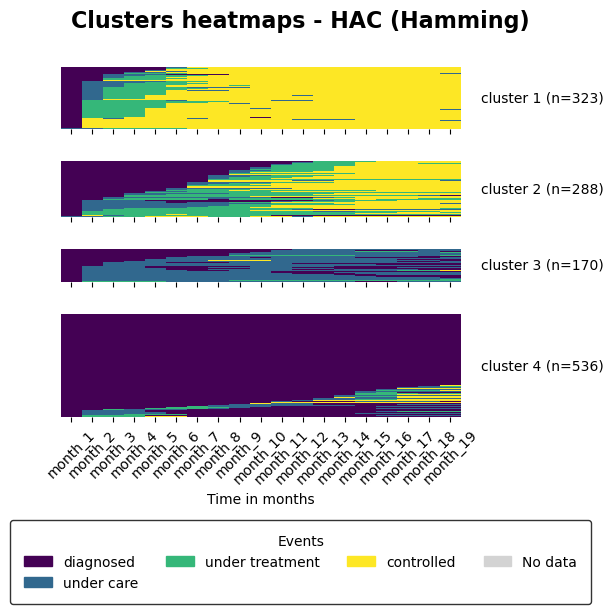

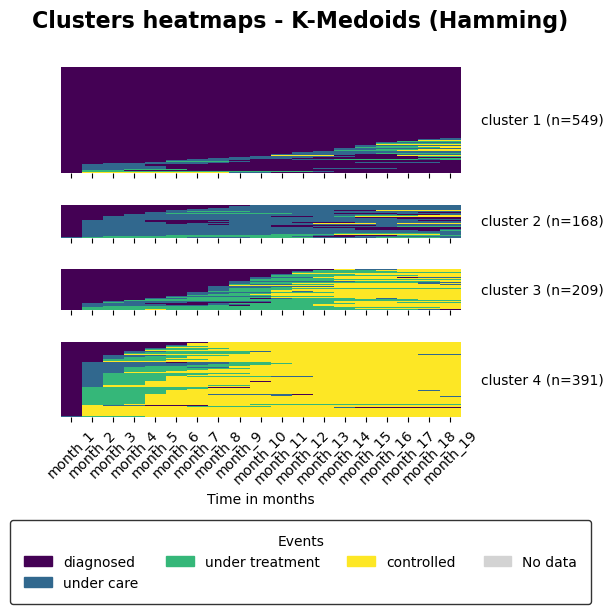

In [17]:
clusters_ham = tca.assign_clusters(linkage_matrix_ham, num_clusters=4)

methodes_clustering_ham = {
    "HAC (Hamming)": clusters_ham,
    "K-Medoids (Hamming)": kmedoids_labels_ham,
}

for titre, labels in methodes_clustering_ham.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Clusters heatmaps - {titre}")

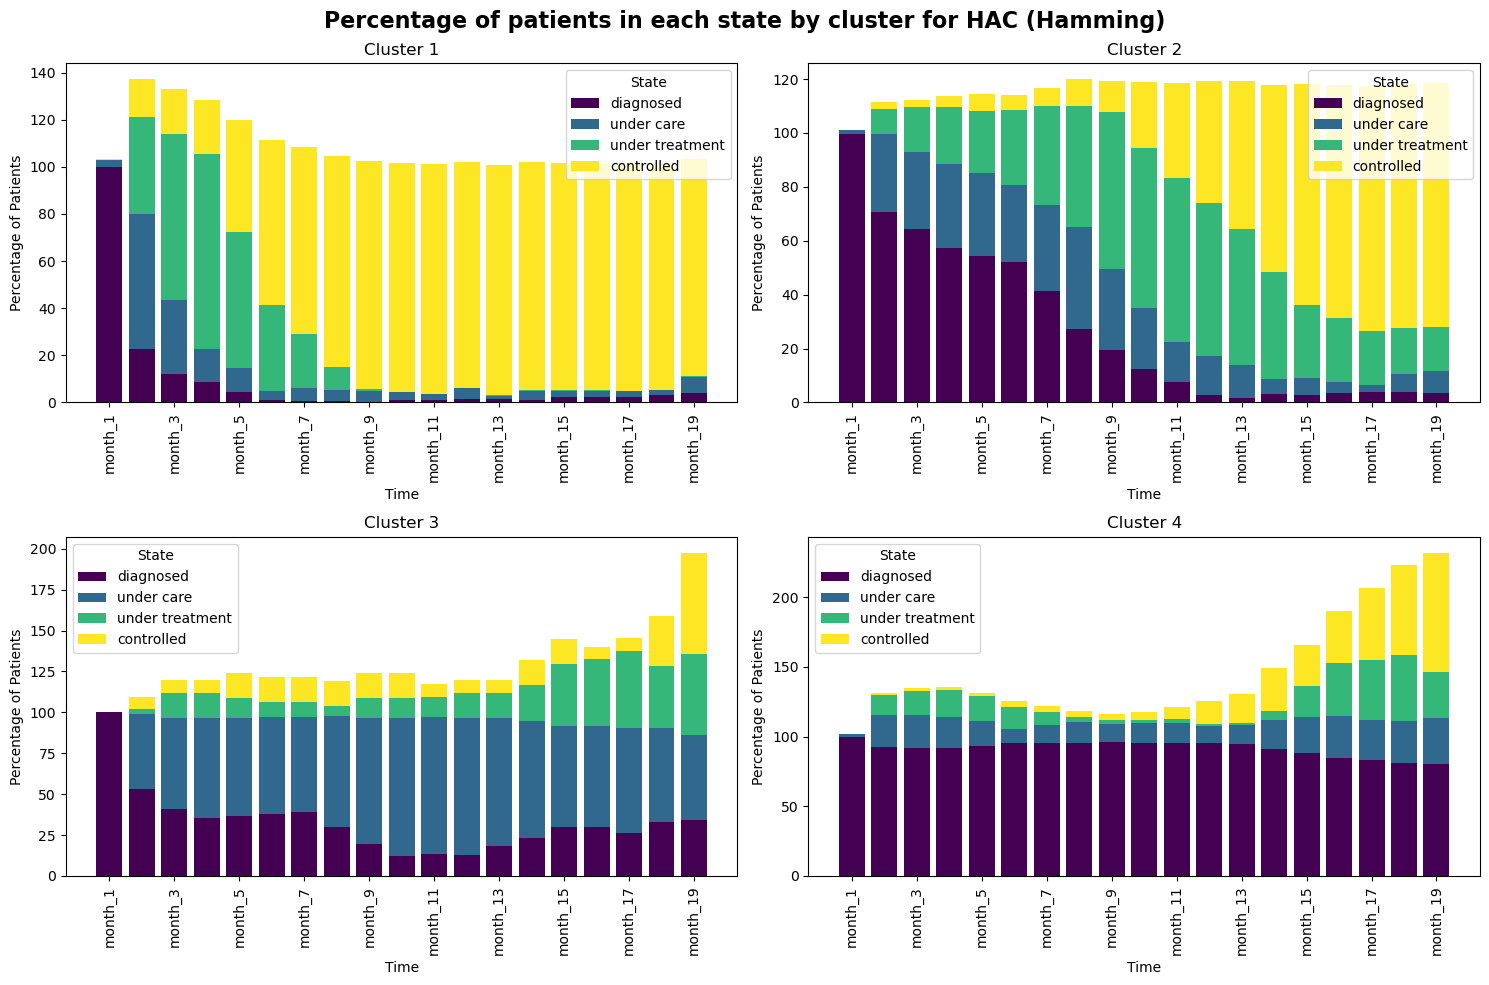

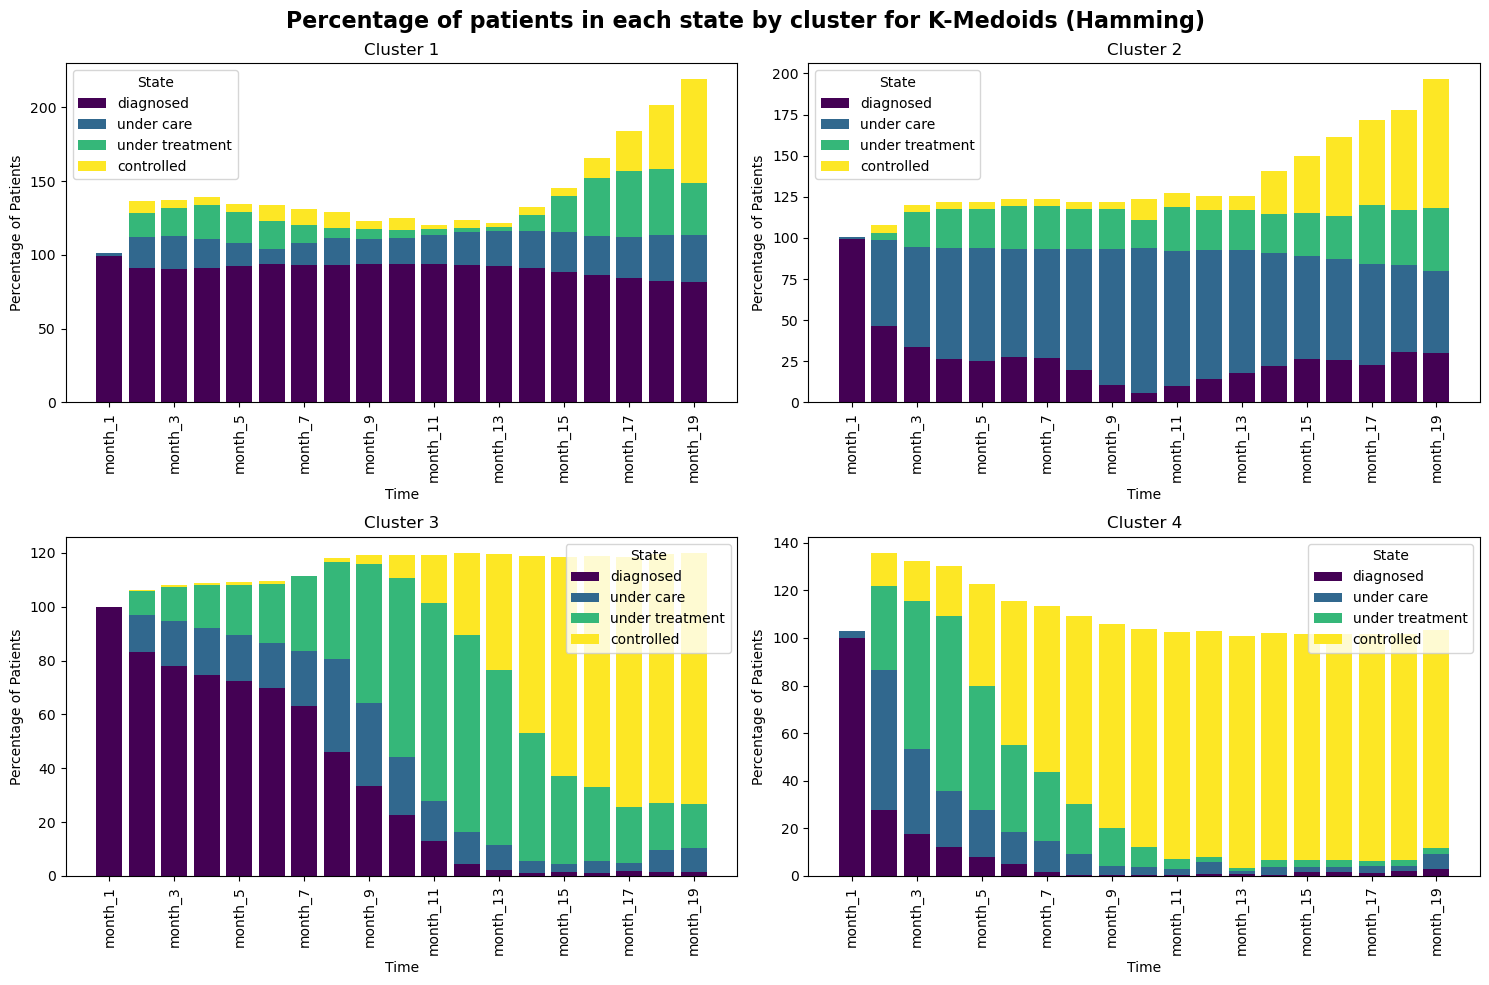

In [18]:
tca.bar_treatment_percentage(clusters=clusters_ham, title="Percentage of patients in each state by cluster for HAC (Hamming)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_ham, title="Percentage of patients in each state by cluster for K-Medoids (Hamming)")

## 4.2. Levenshtein Distance

### 4.2.1. HAC

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


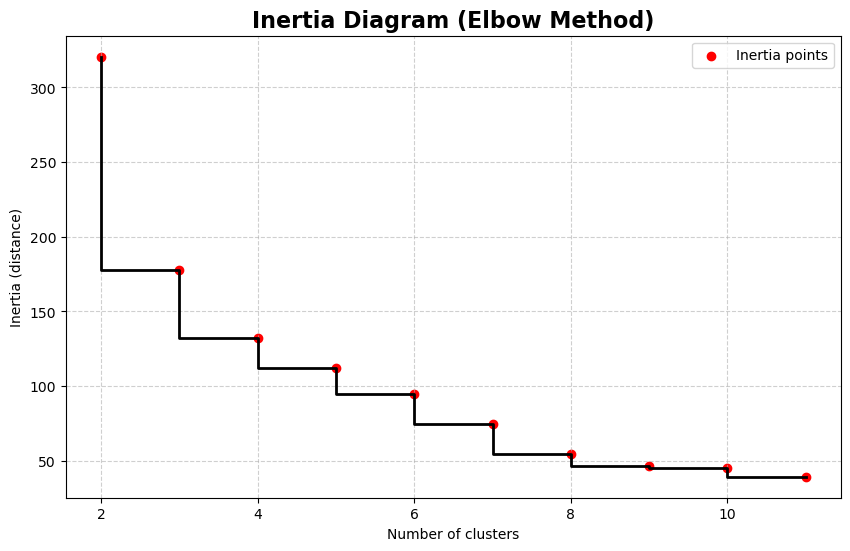

In [19]:
# HAC
linkage_matrix_lev = tca.hierarchical_clustering(distance_matrix_lev)
#tca.plot_clustermap(tca.data,linkage_matrix_lev)
tca.plot_inertia(linkage_matrix_lev)

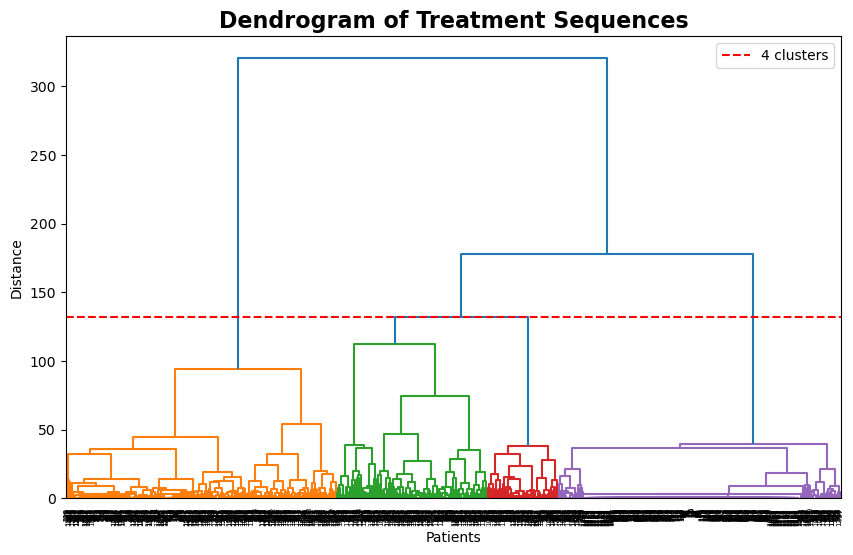

In [20]:
tca.plot_dendrogram(linkage_matrix_lev, n_clusters=4)

### 4.2.2. K-medoids

In [21]:
kmedoids_labels_lev, medoid_indices_lev, inertia_med_lev = tca.kmedoids_clustering(distance_matrix_lev, num_clusters=4,method='fasterpam')
print("kmedoids_labels (Levenshtein) :", np.unique(kmedoids_labels_lev))
print("medoid_indices (Levenshtein) :", medoid_indices_lev)
print("inertia (Levenshtein) :", inertia_med_lev)

INFO:root:Performing K-Medoids clustering with 4 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Levenshtein) : [1 2 3 4]
medoid_indices (Levenshtein) : [ 260 1305  779  456]
inertia (Levenshtein) : 4658.0


### 4.2.3. Heatmaps

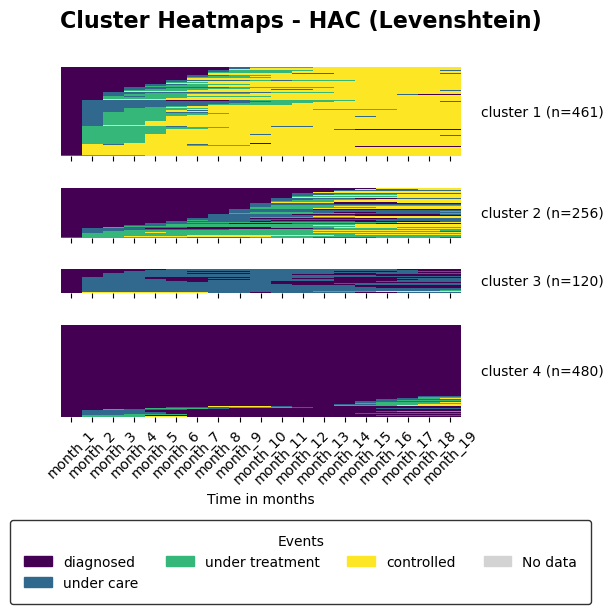

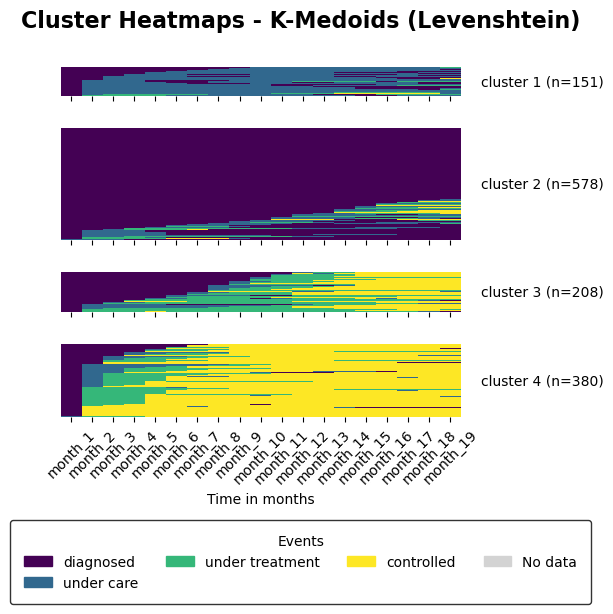

In [22]:
clusters_lev = tca.assign_clusters(linkage_matrix_lev, num_clusters=4)

methodes_clustering_lev = {
    "HAC (Levenshtein)": clusters_lev,
    "K-Medoids (Levenshtein)": kmedoids_labels_lev,
}

for titre, labels in methodes_clustering_lev.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Cluster Heatmaps - {titre}")

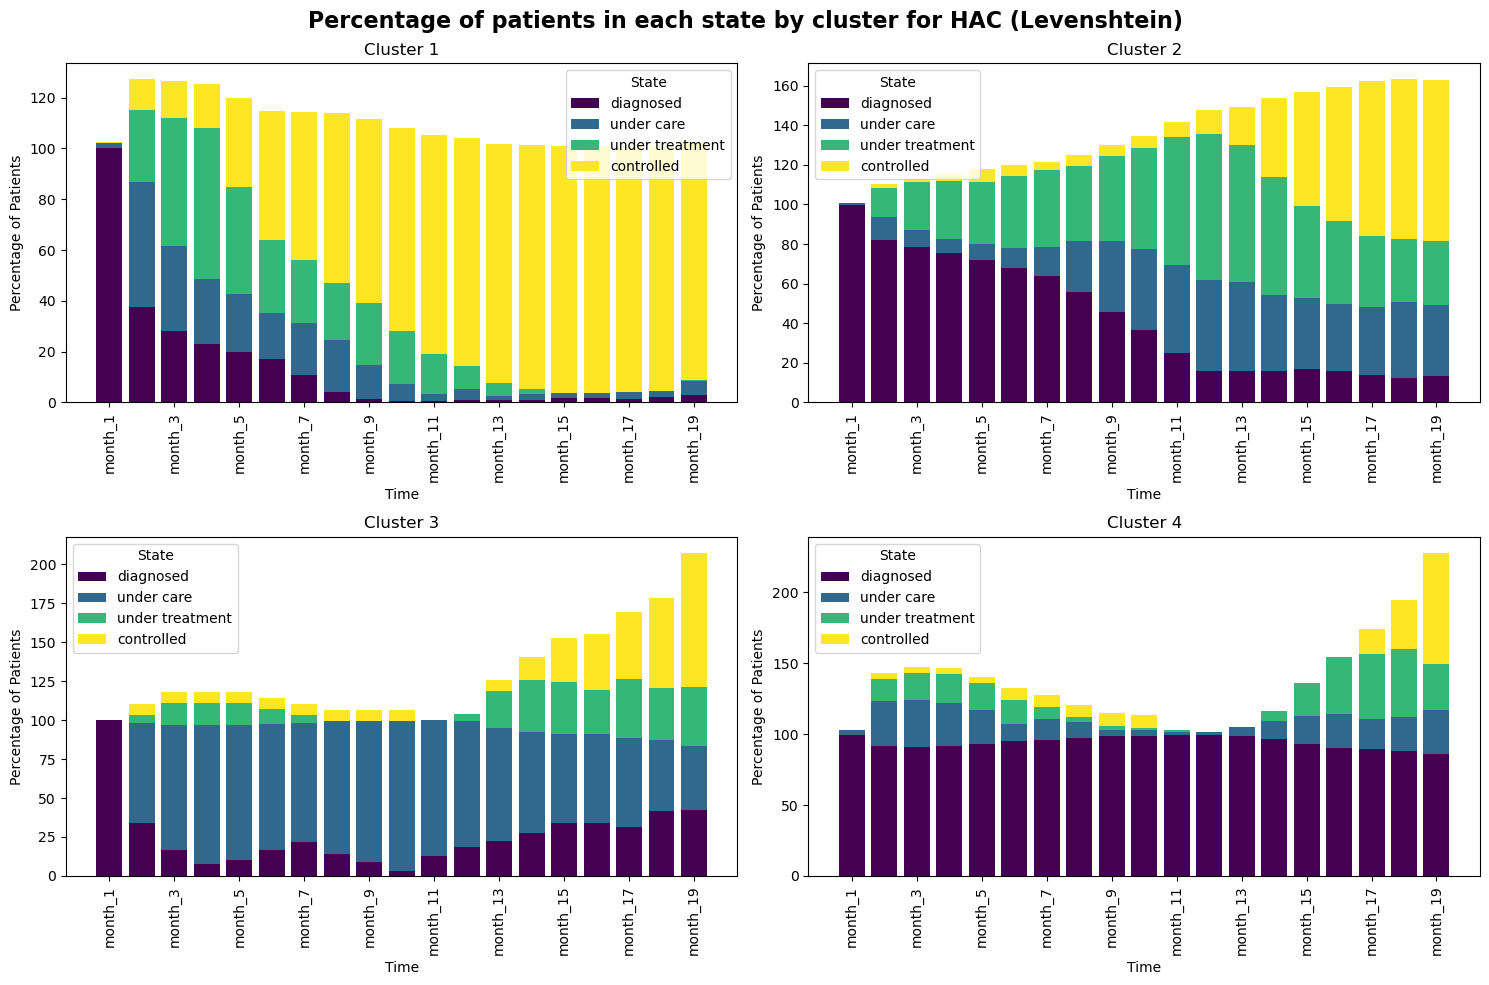

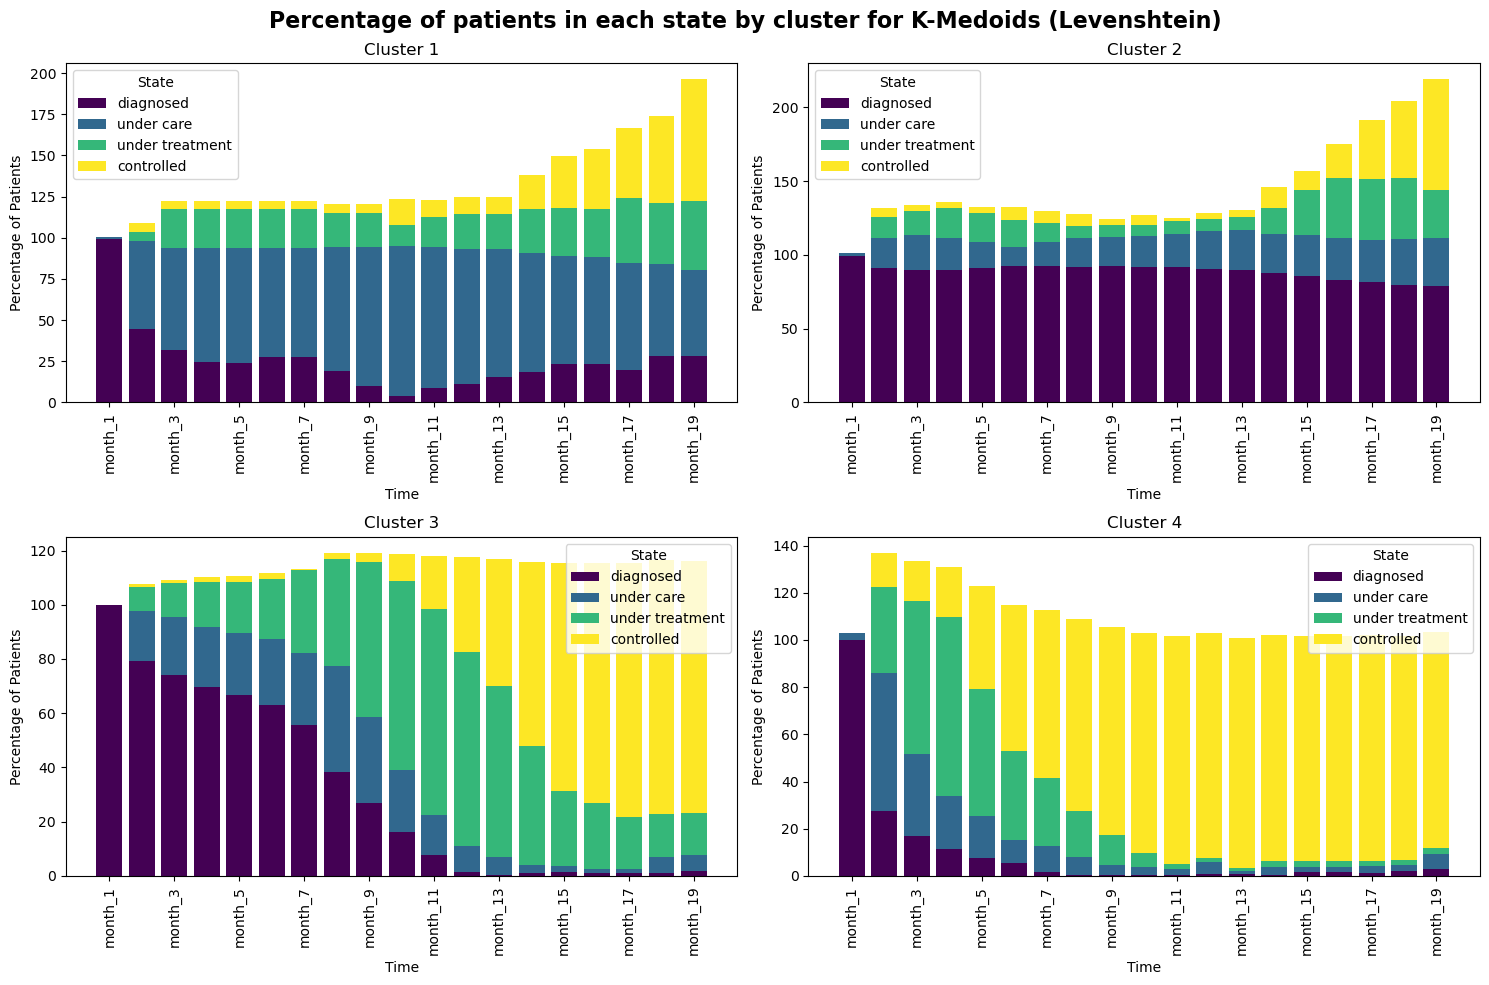

In [23]:
tca.bar_treatment_percentage(clusters=clusters_lev, title="Percentage of patients in each state by cluster for HAC (Levenshtein)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_lev, title="Percentage of patients in each state by cluster for K-Medoids (Levenshtein)")

## 4.3. Optimal Matching Distance

#### 4.3.1. HAC

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


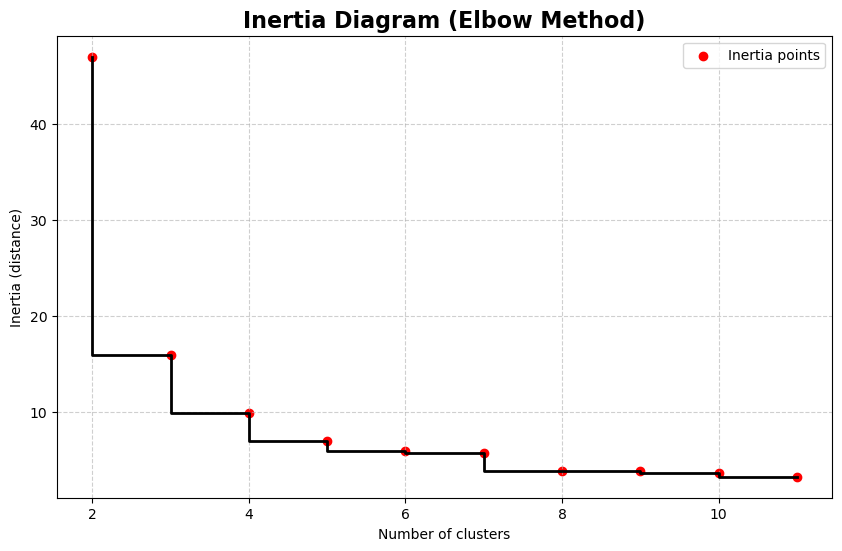

In [24]:
# HAC
linkage_matrix_OM = tca.hierarchical_clustering(distance_matrix_OM)
#tca.plot_clustermap(tca.data,linkage_matrix_OM)
tca.plot_inertia(linkage_matrix_OM)

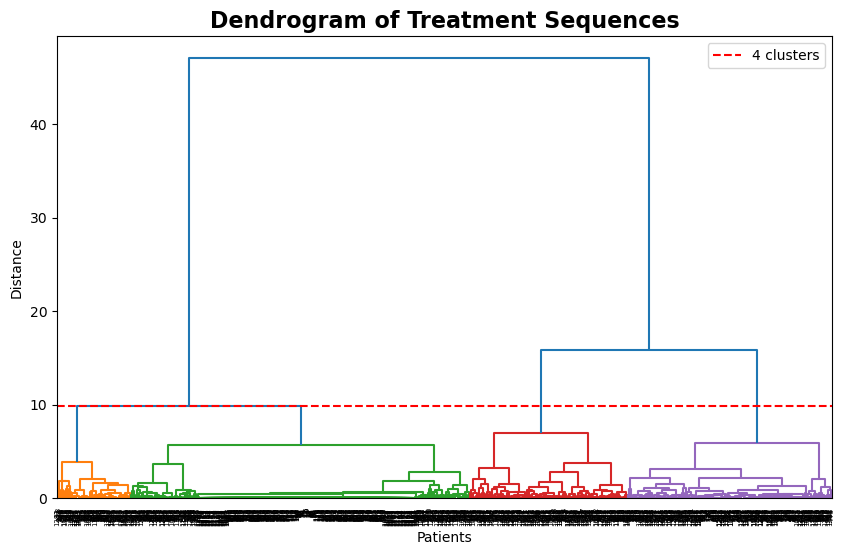

In [25]:
tca.plot_dendrogram(linkage_matrix_OM, n_clusters=4)

### 4.3.2. K-medoids

In [26]:
kmedoids_labels_OM, medoid_indices_OM, inertia_med_OM = tca.kmedoids_clustering(distance_matrix_OM, num_clusters=4,method='fasterpam')
print("kmedoids_labels (Optimal Matching) :", np.unique(kmedoids_labels_OM))
print("medoid_indices (Optimal Matching) :", medoid_indices_OM)
print("inertia (Optimal Matching) :", inertia_med_OM)

INFO:root:Performing K-Medoids clustering with 4 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Optimal Matching) : [1 2 3 4]
medoid_indices (Optimal Matching) : [  22 1210  773  752]
inertia (Optimal Matching) : 309.3157894736843


### 4.3.3. K-means

In [27]:
print('Method 1 – K-means Clustering Based on Frequency')
kmeans_freq_labels, centers_freq, inertia_means_freq = tca.kmeans_on_frequency(num_clusters=4, random_state=42, normalize=False)
print("Labels (Fréquence):", np.unique(kmeans_freq_labels))
#print("Centers (Frequence):", centers_freq)
print("Inertia (Fréquence):", inertia_means_freq)

print('-----------------------------------------------------------------------------------------------')

print('Method 2 – K-means Clustering on Wide Format')
kmeans_wide_labels, centers_wide, inertia_means_wide = tca.kmeans_on_wide_format(num_clusters=4, random_state=42, normalize=False)
print("Labels (Wide):", np.unique(kmeans_wide_labels))
#print("Centers (Wide):", centers_wide)
print("Inertia (Wide):", inertia_means_wide)

INFO:root:Performing K-Means clustering with 4 clusters...


Method 1 – K-means Clustering Based on Frequency


INFO:root:K-Means clustering completed.
INFO:root:Performing KMeans clustering on wide-format data with 4 clusters.
INFO:root:KMeans on wide format completed.


Labels (Fréquence): [1 2 3 4]
Inertia (Fréquence): 25333.356114195805
-----------------------------------------------------------------------------------------------
Method 2 – K-means Clustering on Wide Format
Labels (Wide): [1 2 3 4]
Inertia (Wide): 6899.396856973362


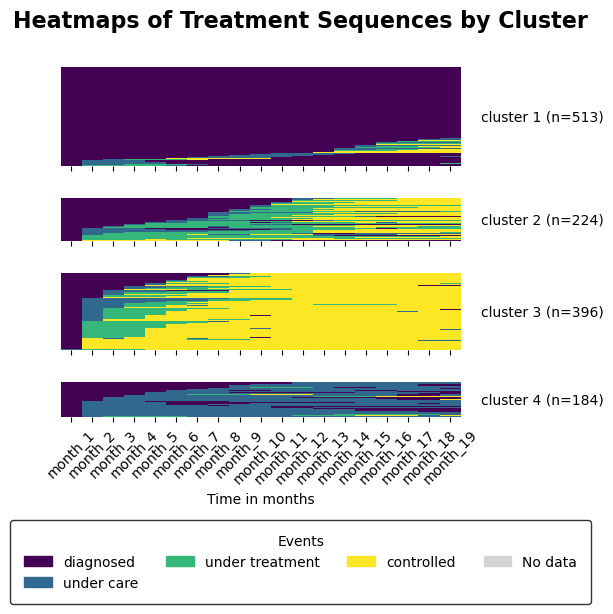

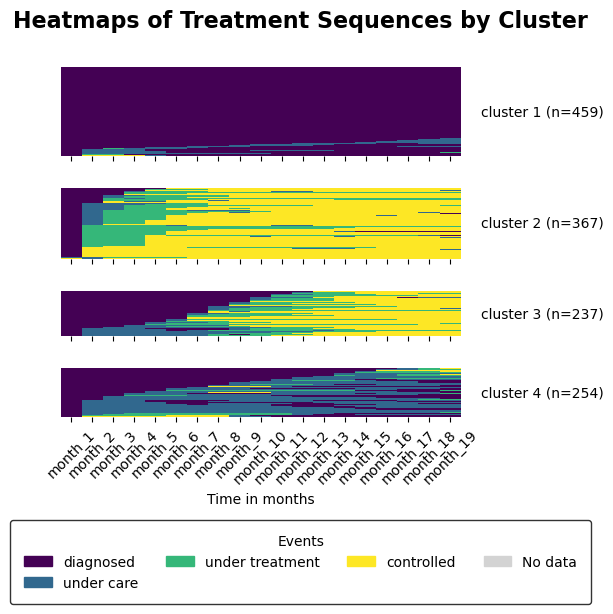

In [28]:
tca.plot_cluster_heatmaps(tca.data, kmeans_freq_labels, sorted=True)
tca.plot_cluster_heatmaps(tca.data, kmeans_wide_labels, sorted=True)

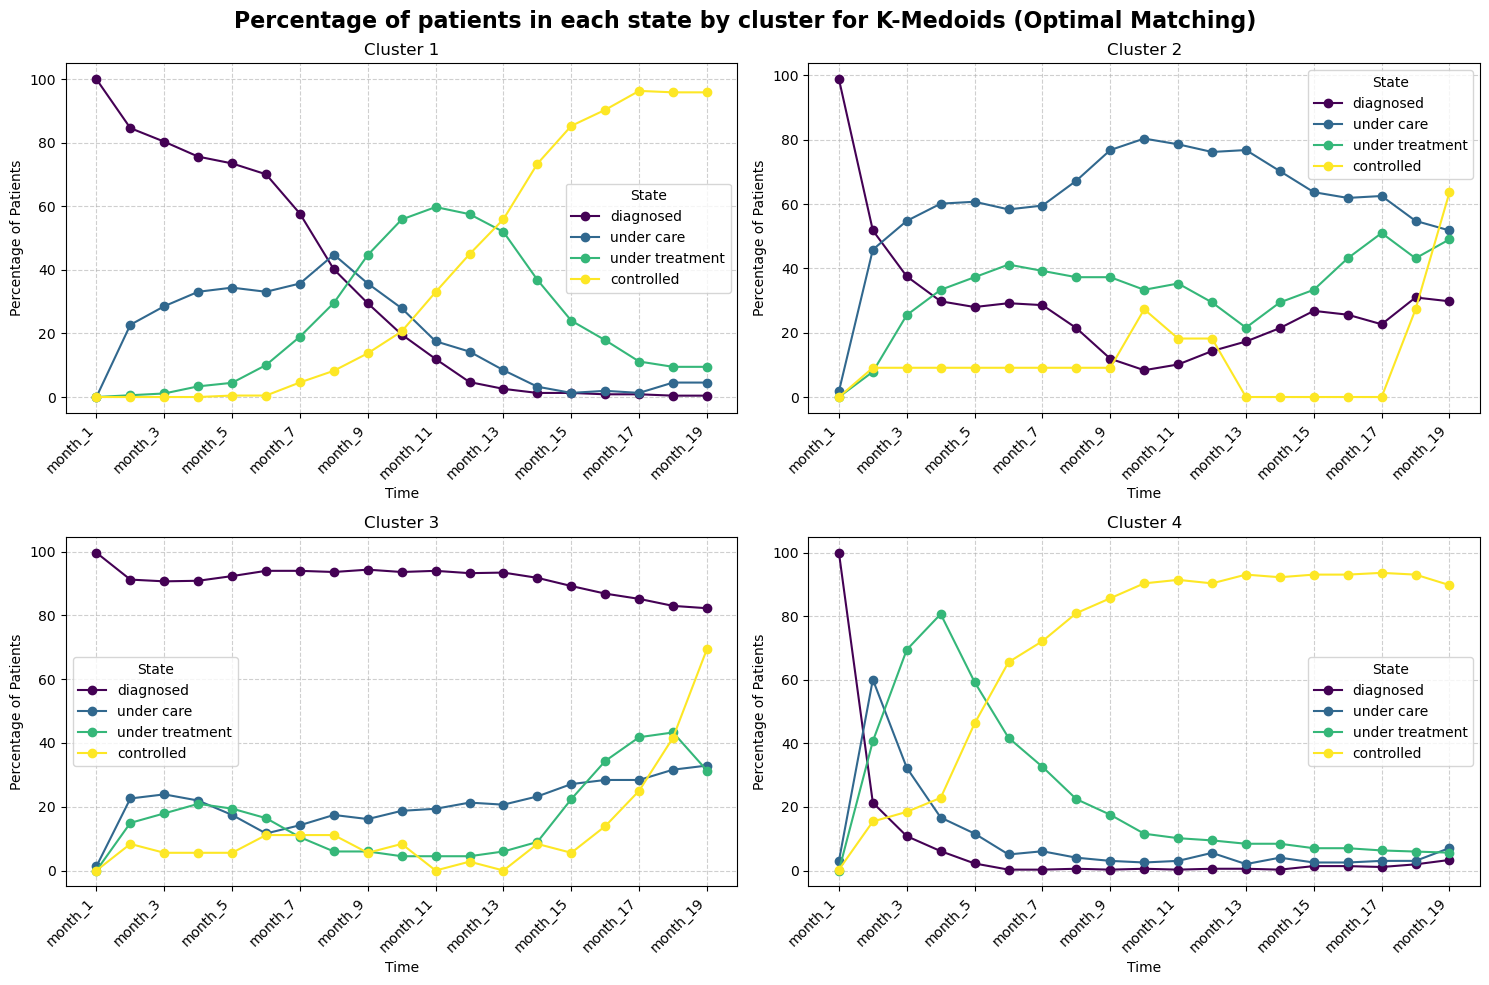

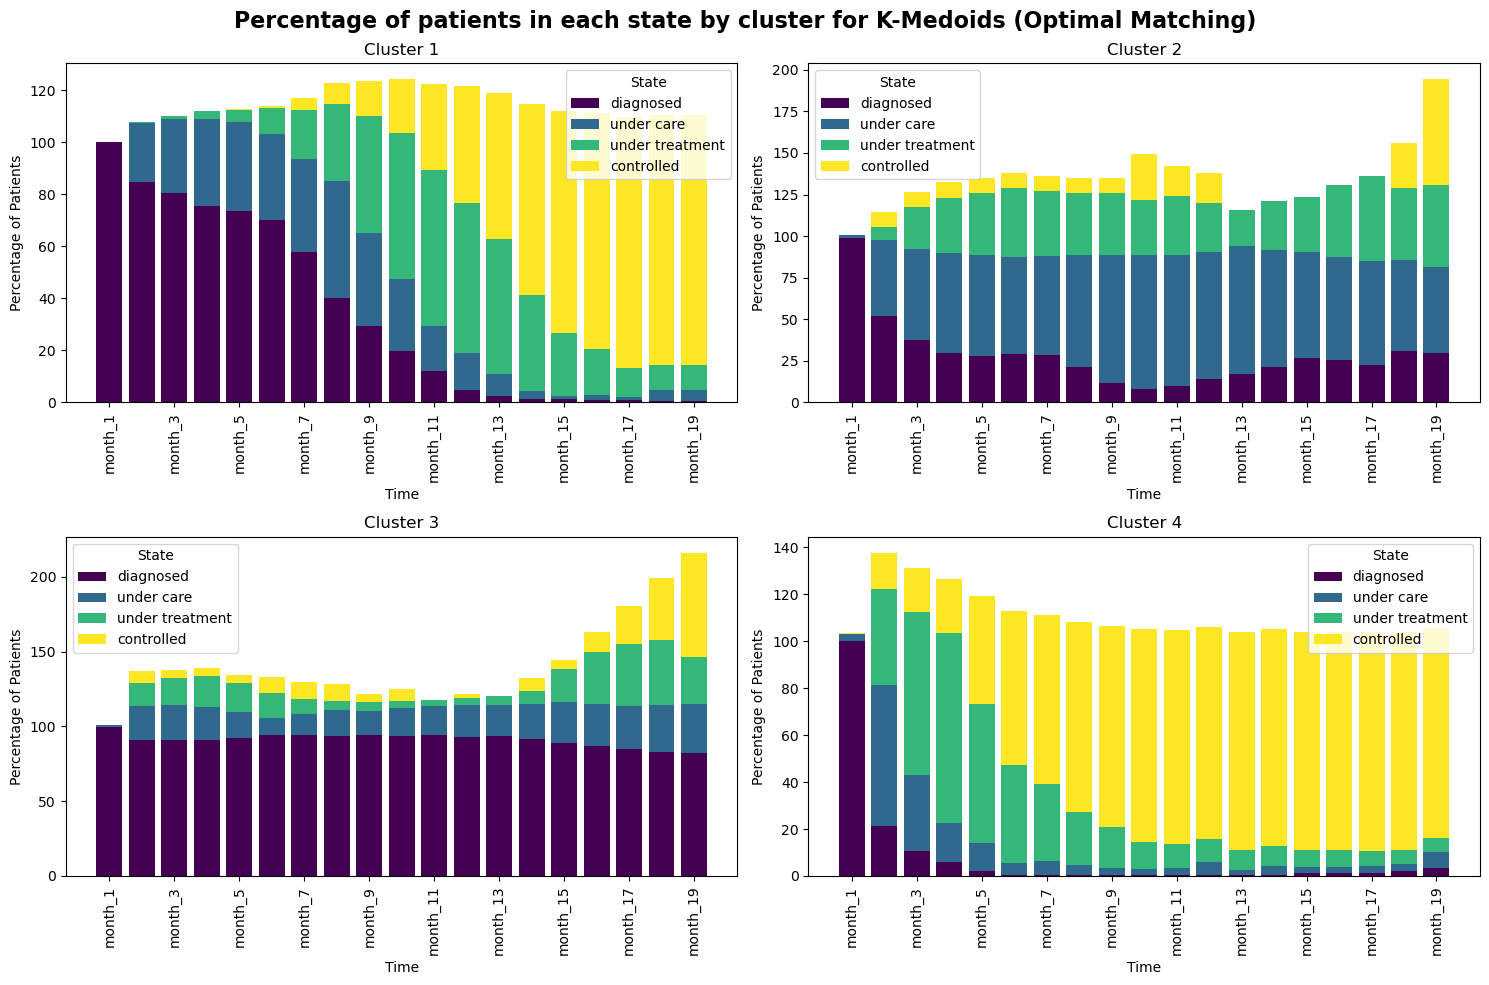

In [29]:
tca.plot_treatment_percentage(clusters=kmedoids_labels_OM, title="Percentage of patients in each state by cluster for K-Medoids (Optimal Matching)")

tca.bar_treatment_percentage(clusters=kmedoids_labels_OM, title="Percentage of patients in each state by cluster for K-Medoids (Optimal Matching)")

### 4.3.4. Comparison

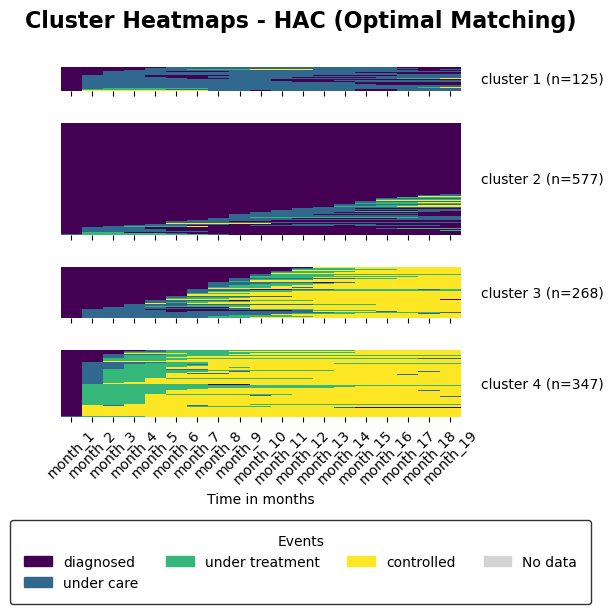

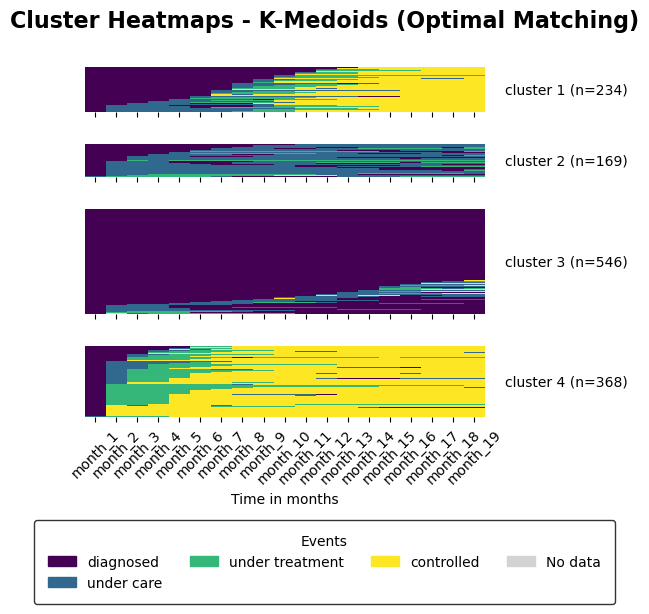

In [30]:
clusters_OM = tca.assign_clusters(linkage_matrix_OM, num_clusters=4)

methodes_clustering_OM = {
    "HAC (Optimal Matching)": clusters_OM,
    "K-Medoids (Optimal Matching)": kmedoids_labels_OM,
}

for titre, labels in methodes_clustering_OM.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Cluster Heatmaps - {titre}")

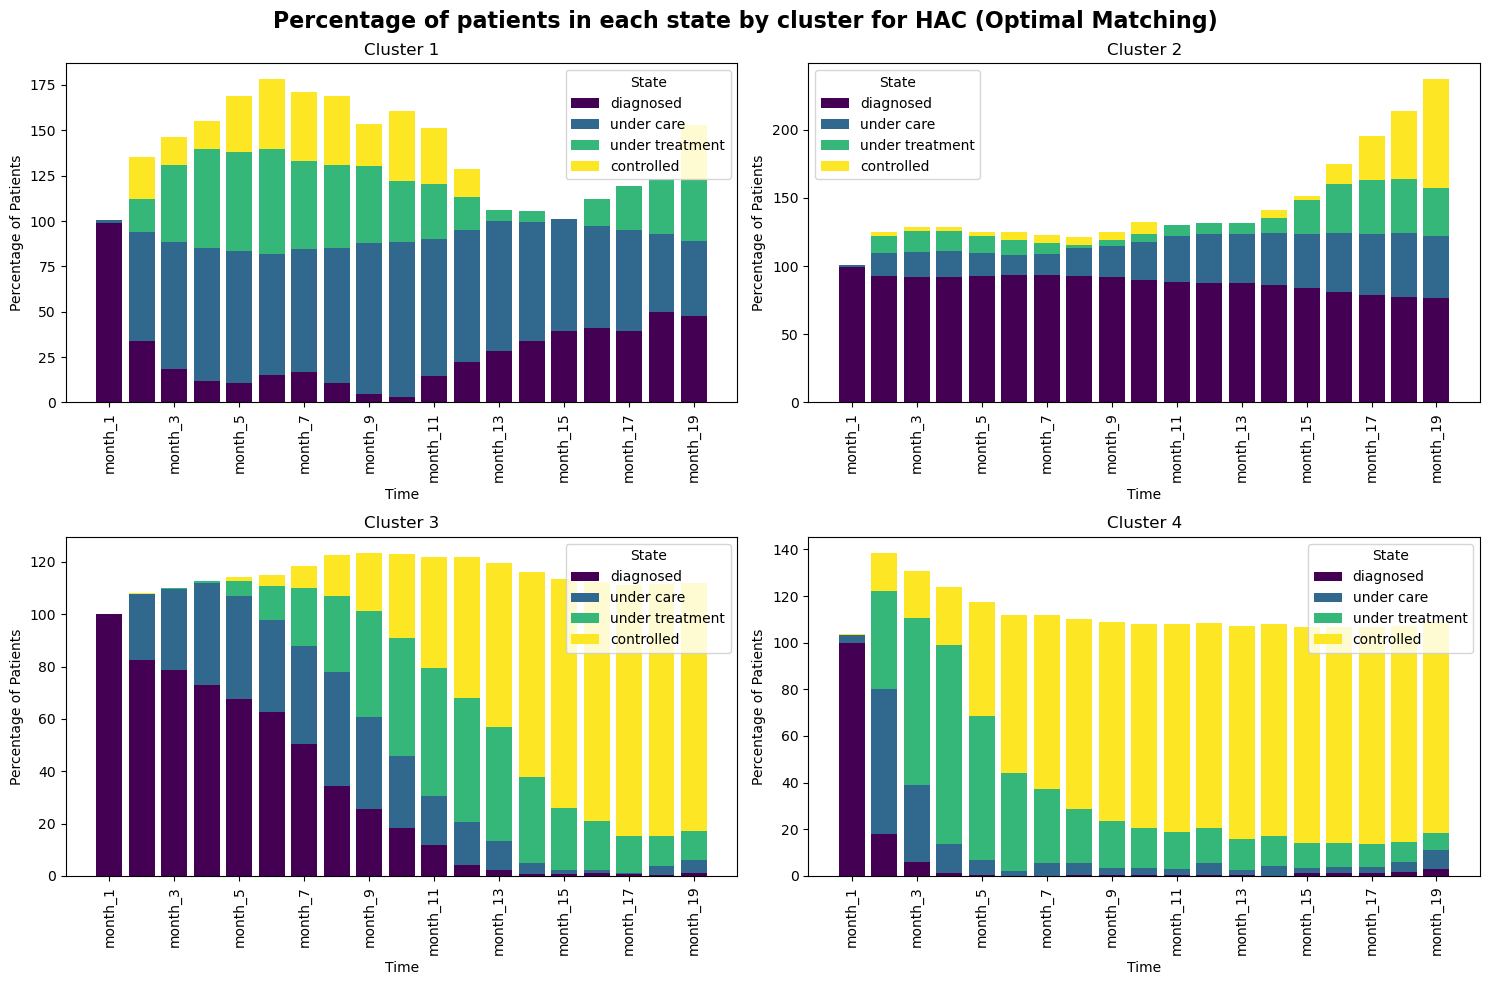

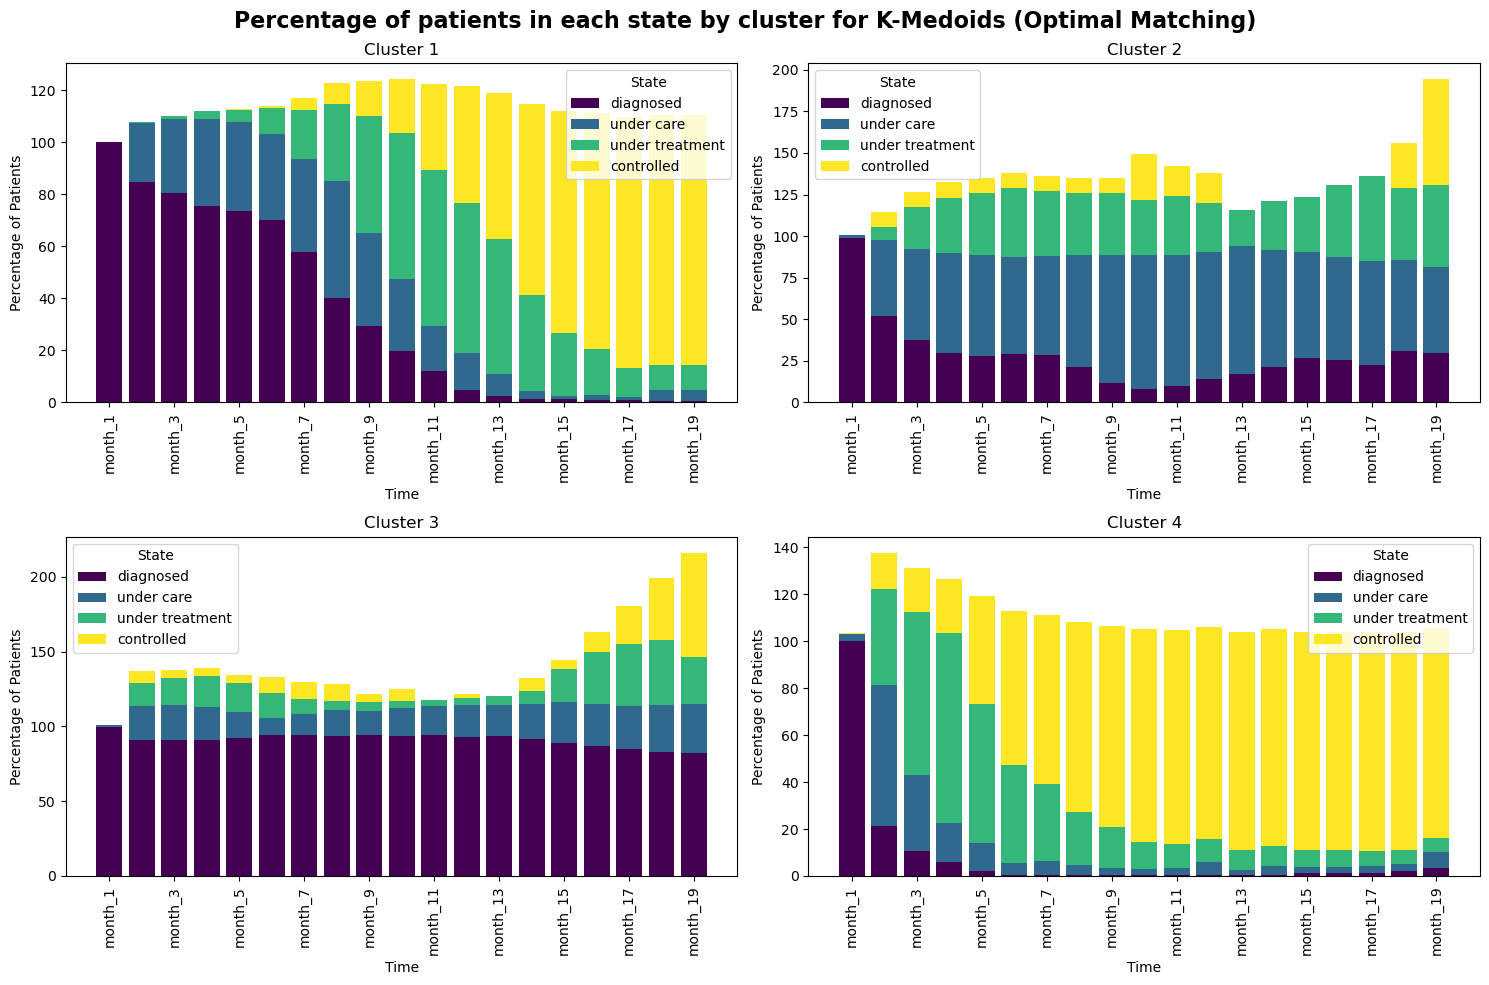

In [31]:
tca.bar_treatment_percentage(clusters=clusters_OM, title="Percentage of patients in each state by cluster for HAC (Optimal Matching)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_OM, title="Percentage of patients in each state by cluster for K-Medoids (Optimal Matching)")

## 4.4. DTW Distance 

### 4.4.1. HAC 

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


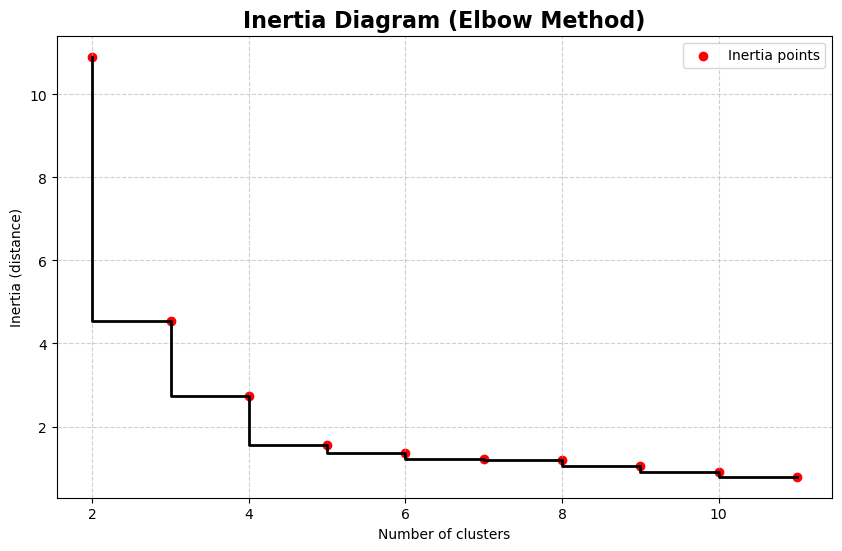

In [33]:
# HAC
linkage_matrix_dtw = tca.hierarchical_clustering(distance_matrix_dtw)
#tca.plot_clustermap(tca.data,linkage_matrix_dtw)
tca.plot_inertia(linkage_matrix_dtw)

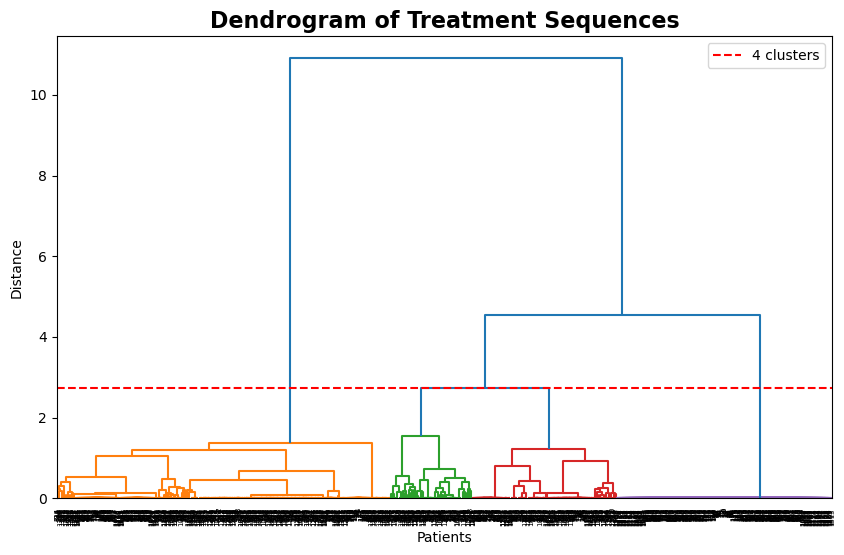

In [34]:
tca.plot_dendrogram(linkage_matrix_dtw, n_clusters=4)

### 4.4.2. K-medoids

In [35]:
kmedoids_labels_dtw, medoid_indices_dtw, inertia_med_dtw = tca.kmedoids_clustering(distance_matrix_dtw, num_clusters=4,method='fasterpam')
print("kmedoids_labels (DTW) :", np.unique(kmedoids_labels_dtw))
print("medoid_indices (DTW) :", medoid_indices_dtw)
print("inertia (DTW) :", inertia_med_dtw)

INFO:root:Performing K-Medoids clustering with 4 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (DTW) : [1 2 3 4]
medoid_indices (DTW) : [371 812  38 454]
inertia (DTW) : 48.00566845409149


### 4.4.3. Heatmaps

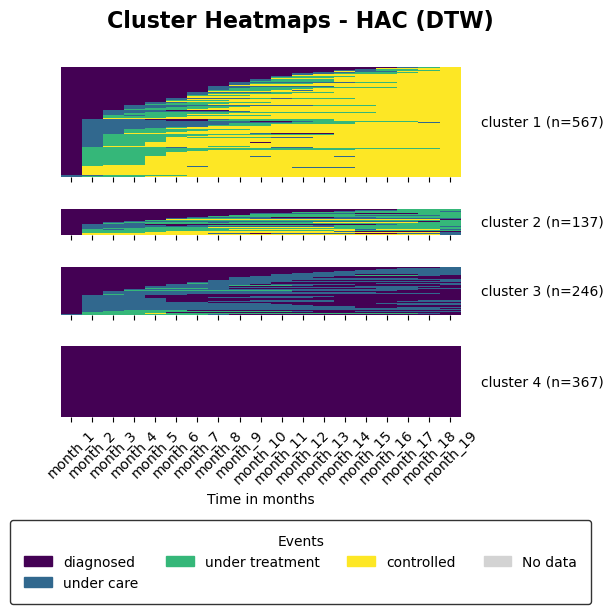

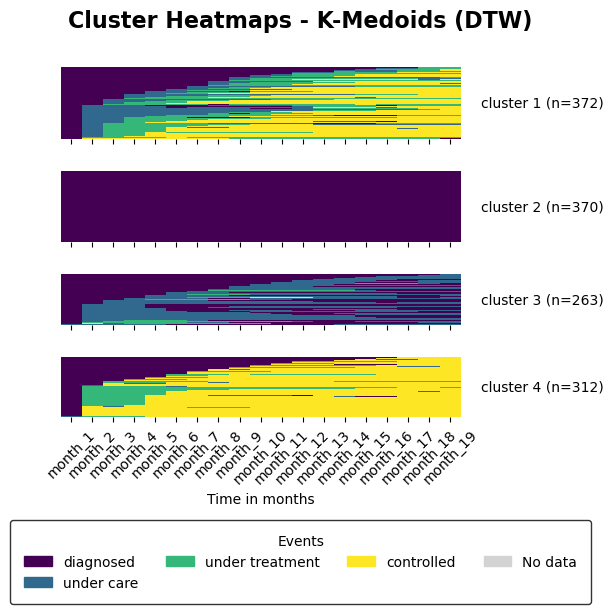

In [36]:
clusters_dtw = tca.assign_clusters(linkage_matrix_dtw, num_clusters=4)

methodes_clustering_dtw = {
    "HAC (DTW)": clusters_dtw,
    "K-Medoids (DTW)": kmedoids_labels_dtw,
}

for titre, labels in methodes_clustering_dtw.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Cluster Heatmaps - {titre}")

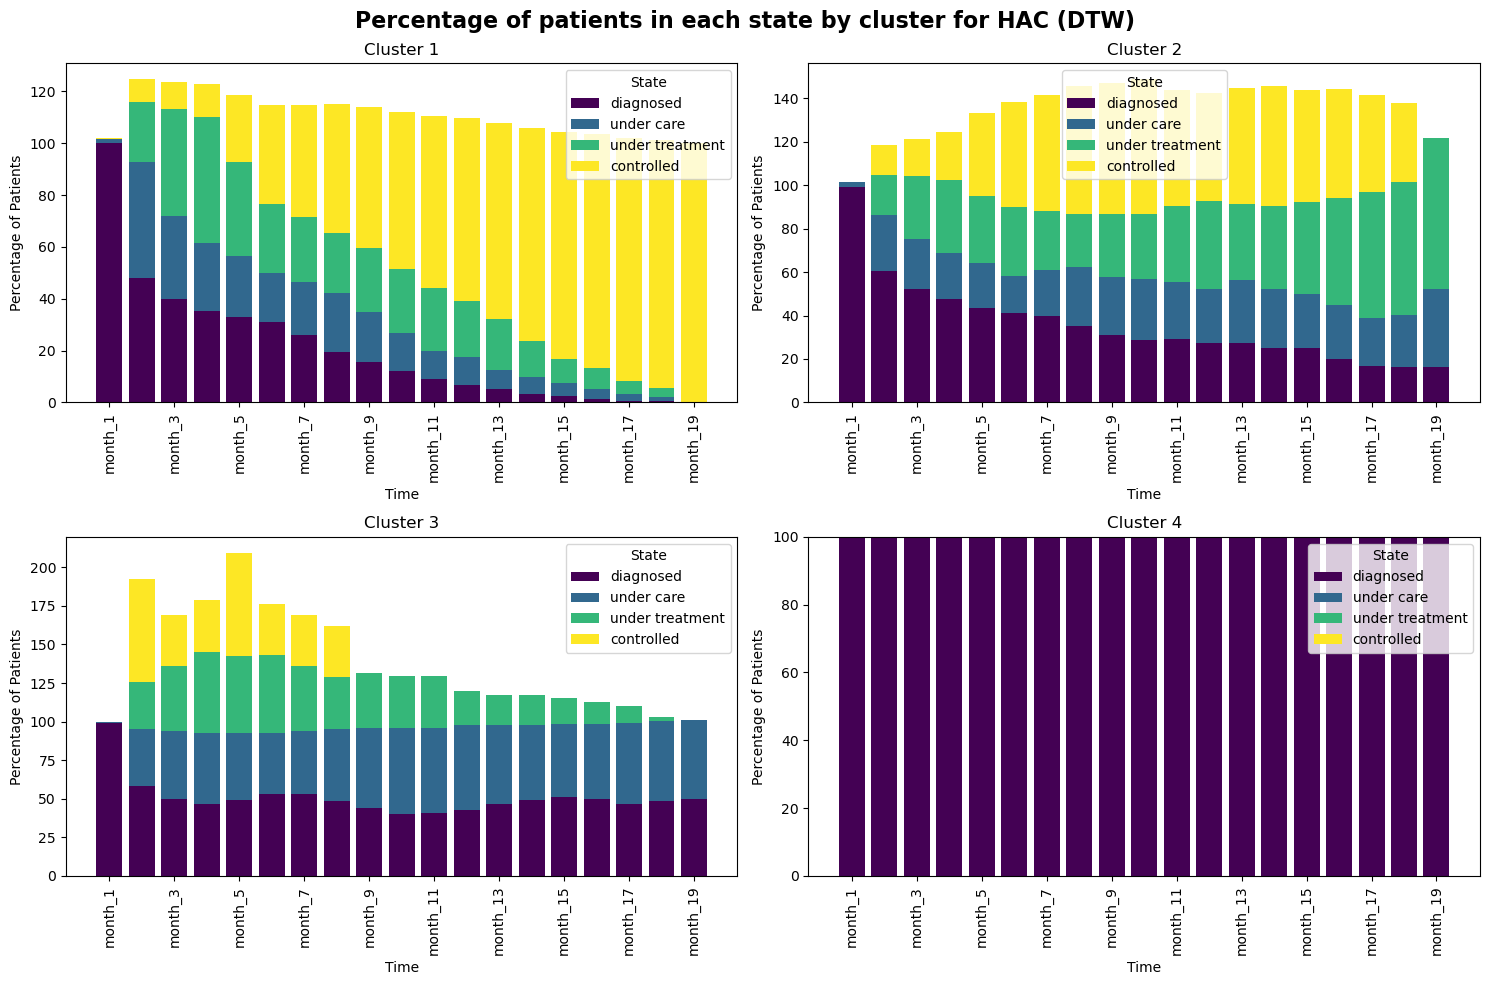

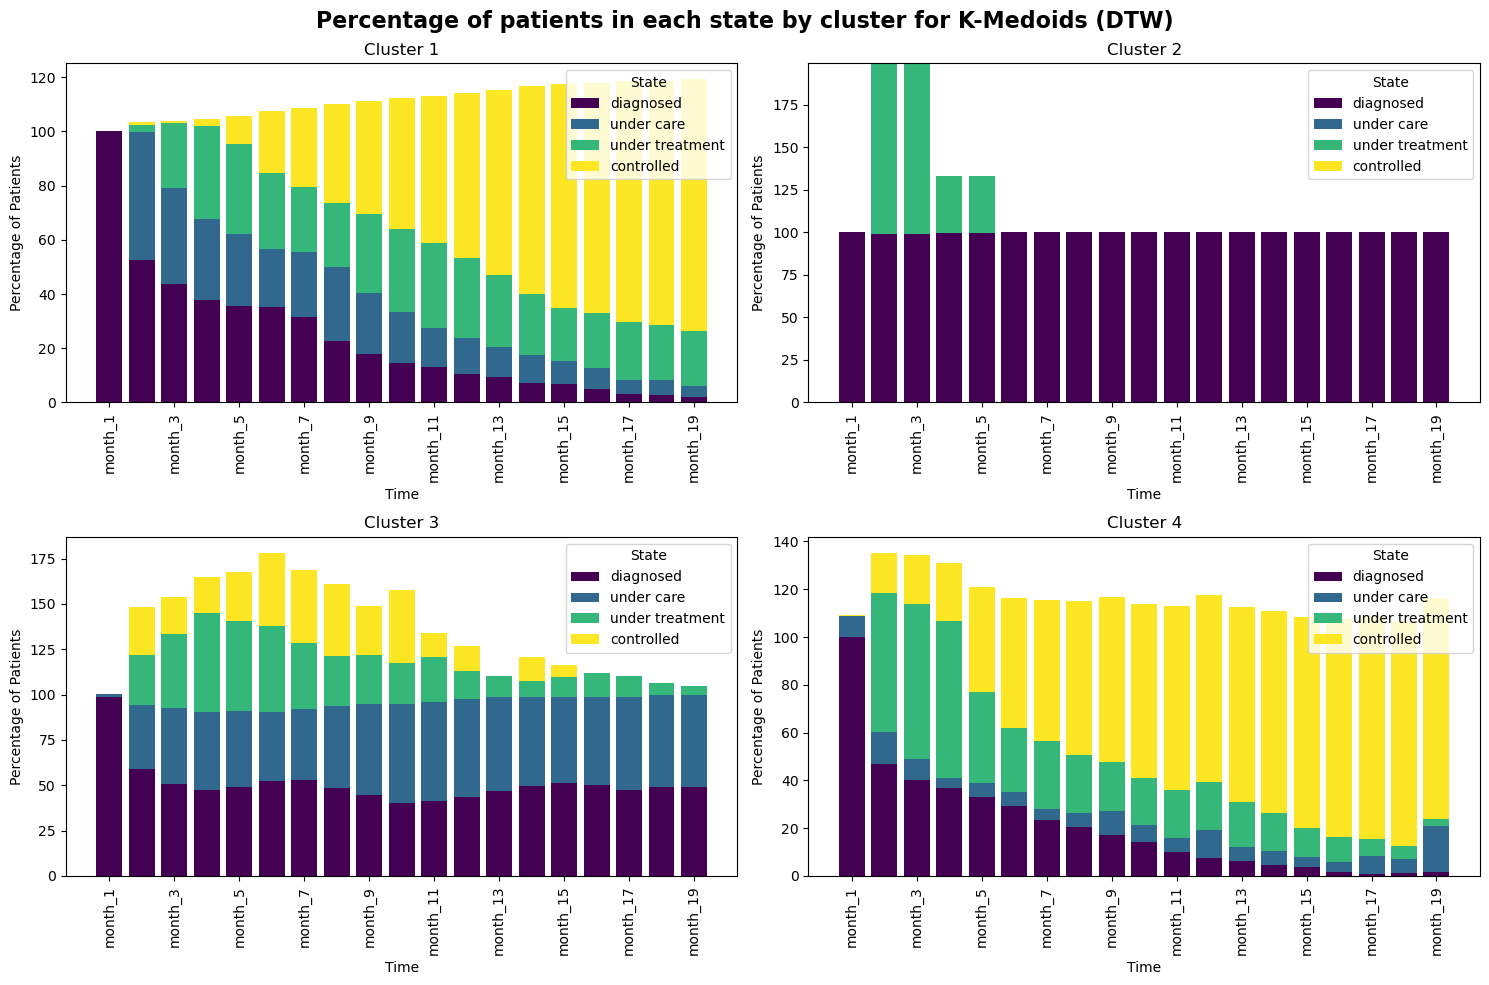

In [37]:
tca.bar_treatment_percentage(clusters=clusters_dtw, title="Percentage of patients in each state by cluster for HAC (DTW)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_dtw, title="Percentage of patients in each state by cluster for K-Medoids (DTW)")

## 4.5. GAK Distance

### 4.5.1. HAC

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


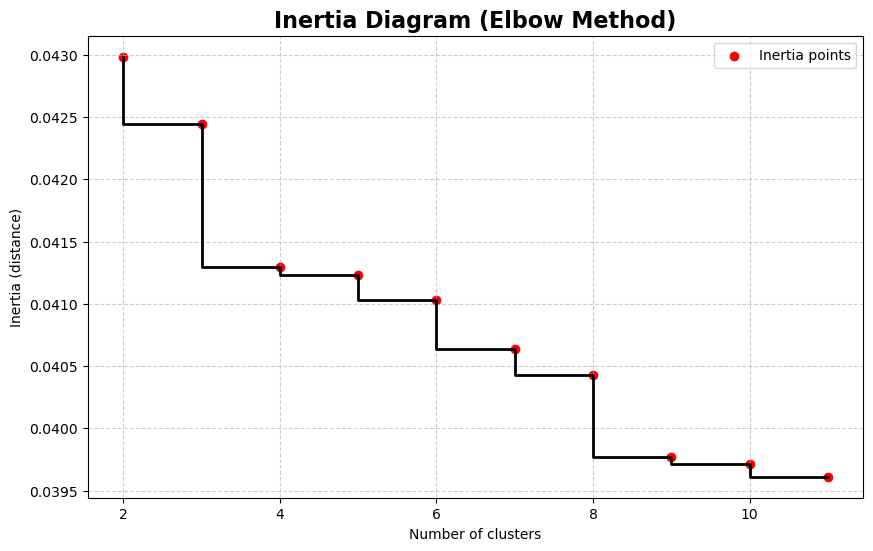

In [38]:
# HAC
linkage_matrix_gak = tca.hierarchical_clustering(distance_matrix_gak)
#tca.plot_clustermap(tca.data,linkage_matrix_gak)
tca.plot_inertia(linkage_matrix_gak)

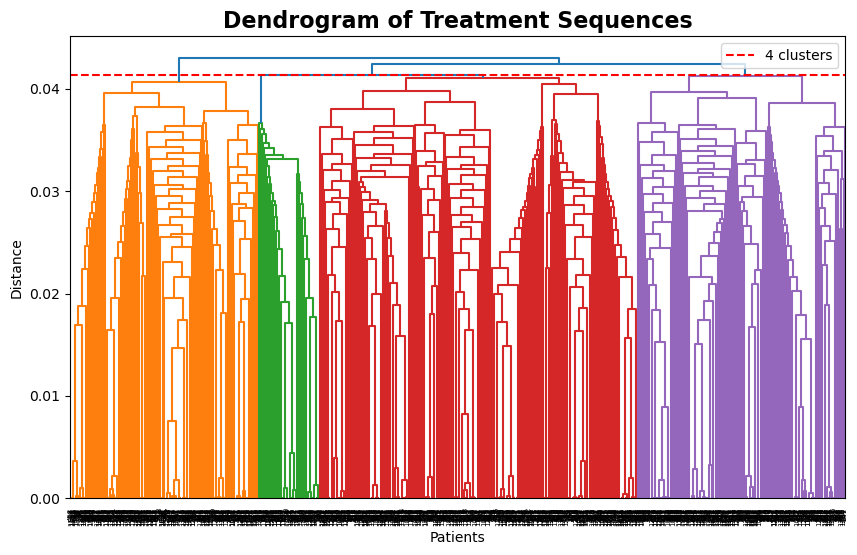

In [39]:
tca.plot_dendrogram(linkage_matrix_gak, n_clusters=4)

### 4.5.2. K-medoids

In [40]:
kmedoids_labels_gak, medoid_indices_gak, inertia_med_gak = tca.kmedoids_clustering(distance_matrix_gak, num_clusters=4,method='fasterpam')
print("kmedoids_labels (GAK) :", np.unique(kmedoids_labels_gak))
print("medoid_indices (GAK) :", medoid_indices_gak)
print("inertia (GAK) :", inertia_med_gak)

INFO:root:Performing K-Medoids clustering with 4 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (GAK) : [1 2 3 4]
medoid_indices (GAK) : [616 735 420 854]
inertia (GAK) : 2.777302155406691e-17


### 4.5.3. Comparison

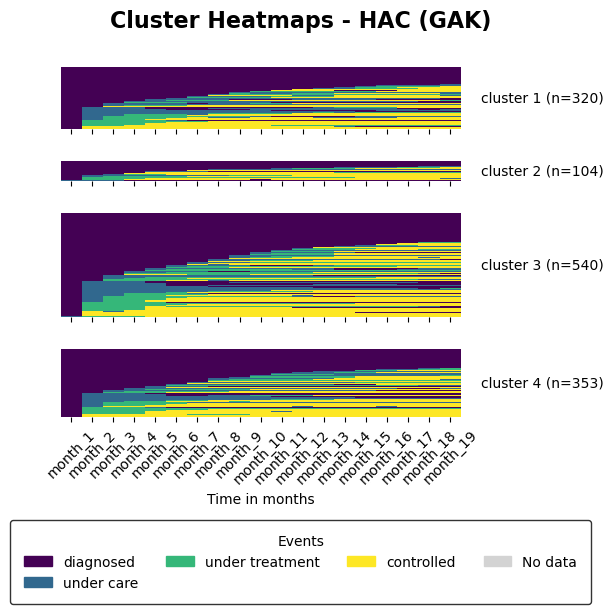

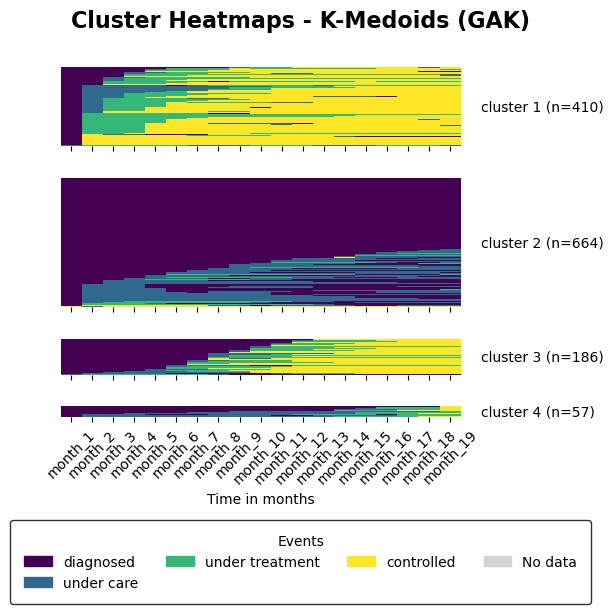

In [41]:
clusters_gak = tca.assign_clusters(linkage_matrix_gak, num_clusters=4)

methodes_clustering_gak = {
    "HAC (GAK)": clusters_gak,
    "K-Medoids (GAK)": kmedoids_labels_gak,
}

for titre, labels in methodes_clustering_gak.items():    
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Cluster Heatmaps - {titre}")

For this distance, with HAC, Cluster 2 accounts for almost all of the patients, while Clusters 1 and 3 account for very few; therefore, it does not allow for generalizations.

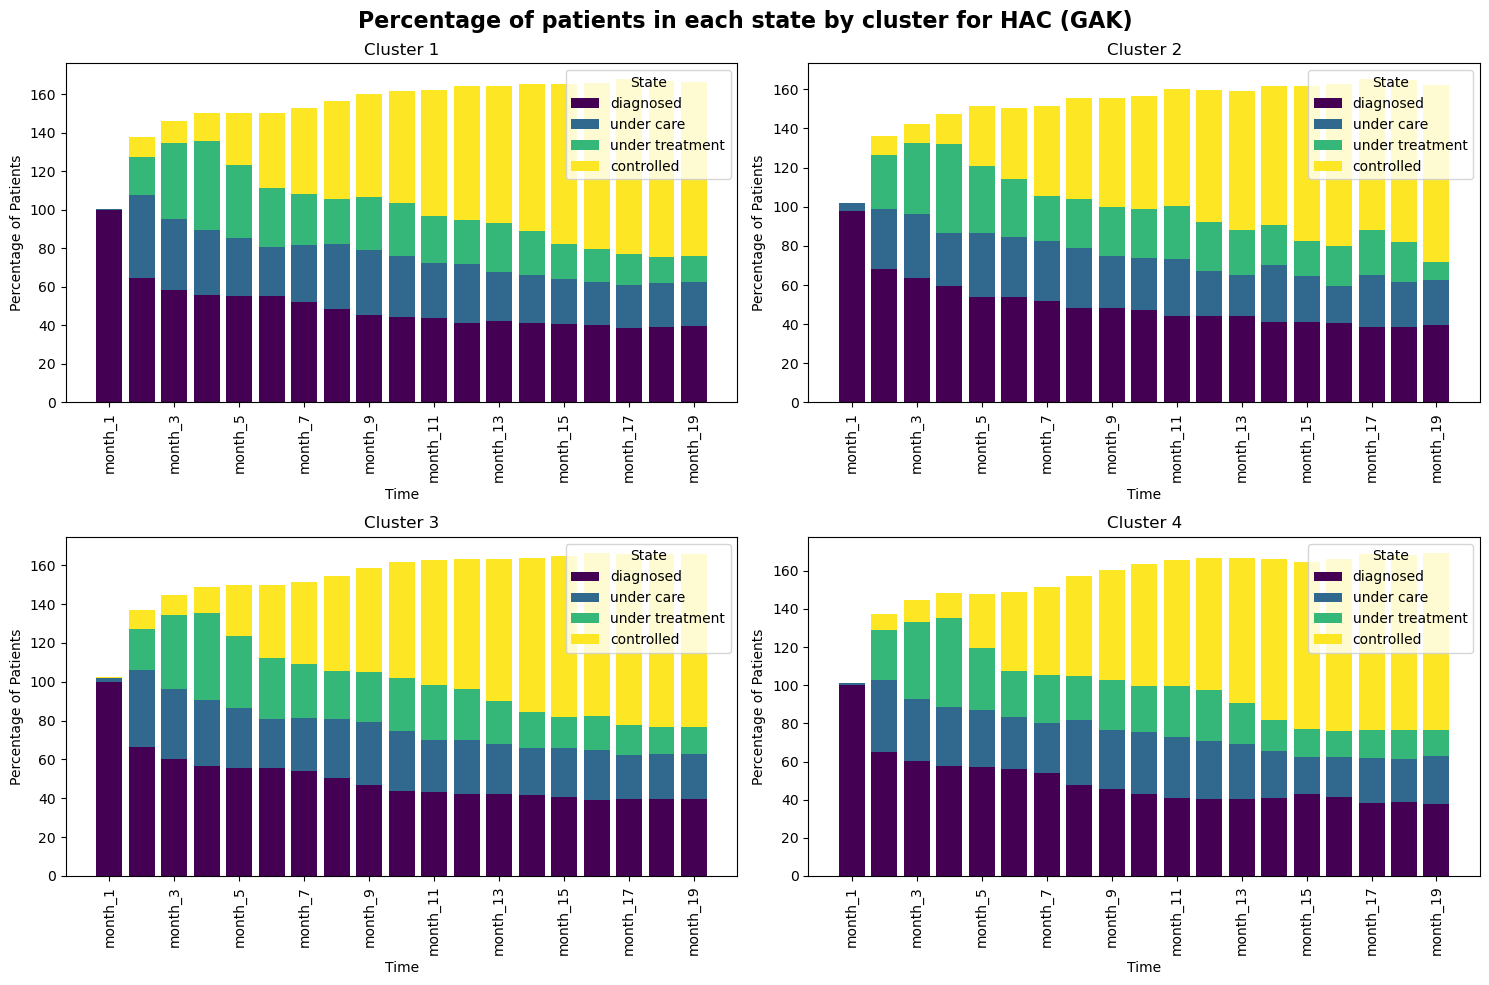

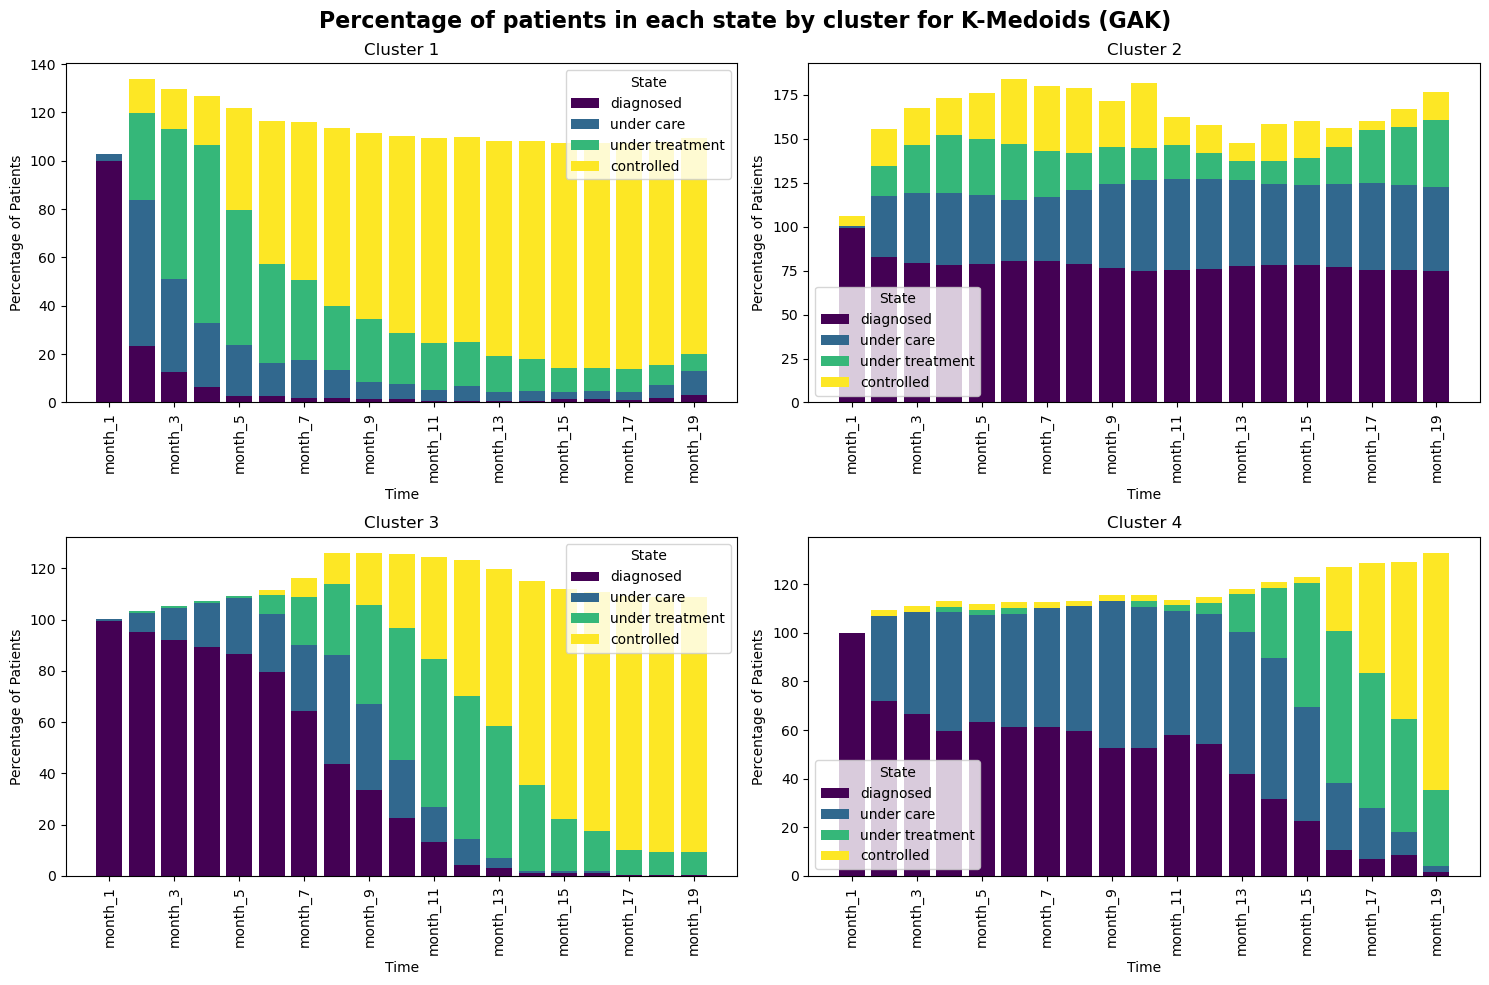

In [42]:
tca.bar_treatment_percentage(clusters=clusters_gak, title="Percentage of patients in each state by cluster for HAC (GAK)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_gak, title="Percentage of patients in each state by cluster for K-Medoids (GAK)")

We note that most of these clusters are resemblant, we recognize 4 groups :

- **Incomplete** ($n = 125$): patients who enter care but do not initiate or sustain treatment over the observation period.
- **Out of care** ($n = 577$): patients who remain predominantly in the diagnosed state throughout, without entering or maintaining engagement in care.
- **Fast** ($n = 268$): patients who rapidly transition through the care cascade and reach controlled infection within the first months.
- **Slow** ($n = 347$): patients who progress through care but at a slower pace, reaching controlled infection only after month 6.

For the following, we will focus on K-medoids with the OM distance

With cluster 1 = Incomplete, cluster 2 = Out of care, cluster 3 = Fast, cluster 4 = Slow.

In [43]:
mapping_noms = {
    1: 'Slow',
    2: 'Incomplete',
    3: 'Out of care',
    4: 'Fast'
}

kmedoids_labels_OM = np.array([mapping_noms[label] for label in kmedoids_labels_OM])

# 5. Additions 

## 5.1. Transversal Entropy (Traminer)
Entropy indicates the degree to which patients are dispersed,or not,at a given time $t$. Entropy measures disorder:
- Entropy = 0: All patients are in the same state (e.g., everyone is in the “Diagnosis” stage).
- Entropy = 1 (maximum): Patients are evenly distributed across all possible states. This represents maximum diversity.

Peak entropy at the beginning: Indicates that patients begin their care journey in very different ways.

Decrease in entropy at the end: This means that the care pathway leads patients toward a common state (often recovery or the end of follow-up).

A cluster with consistently low entropy is a “robust” (predictable) cluster. A cluster with high entropy is an unstable group.

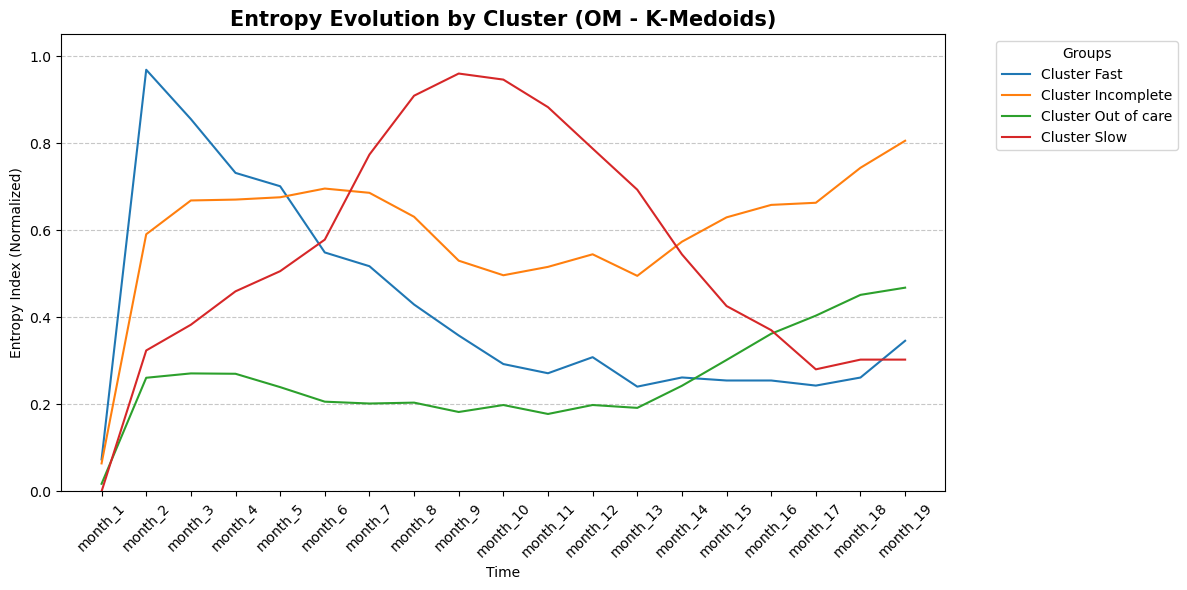

In [44]:
plot_transversal_entropy(tca, clusters=kmedoids_labels_OM, title="Entropy Evolution by Cluster (OM - K-Medoids)")

The entropy index reveals distinct temporal dynamics for each group. 
- The Out of care cluster exhibits a low and stable entropy early on, indicating rapid convergence to a common sequence of states. 
- In contrast, the Slow cluster displays a curve, reaching maximum heterogeneity mid-trajectory before converging to a low entropy level by the end of the follow-up. 
- The Fast cluster is characterized by a massive, immediate spike in entropy at month 2, followed by a steady decline as individuals settle into a stable state. 
- Finally, the Incomplete cluster maintains a consistently high entropy level throughout the entire 19-month period, reflecting heterogenity within the trajectories.

## 5.2. Mean Time Plot (Traminer)

Average Duration by State (Equivalent to `seqmtplot`): This graph shows the total time spent in each phase of the care pathway. It illustrates how long each state lasts.

We observe that Cluster 1 is predominantly characterized by patients remaining in the "Diagnosed" (D) state. In contrast, Cluster 2 displays highly transitional trajectories, passing through all clinical stages of the care cascade, but spending relatively little time in the (S) state. Finally, Cluster 3 is predominantly defined by successful infection control, with patients spending the majority of their observation period in state S.

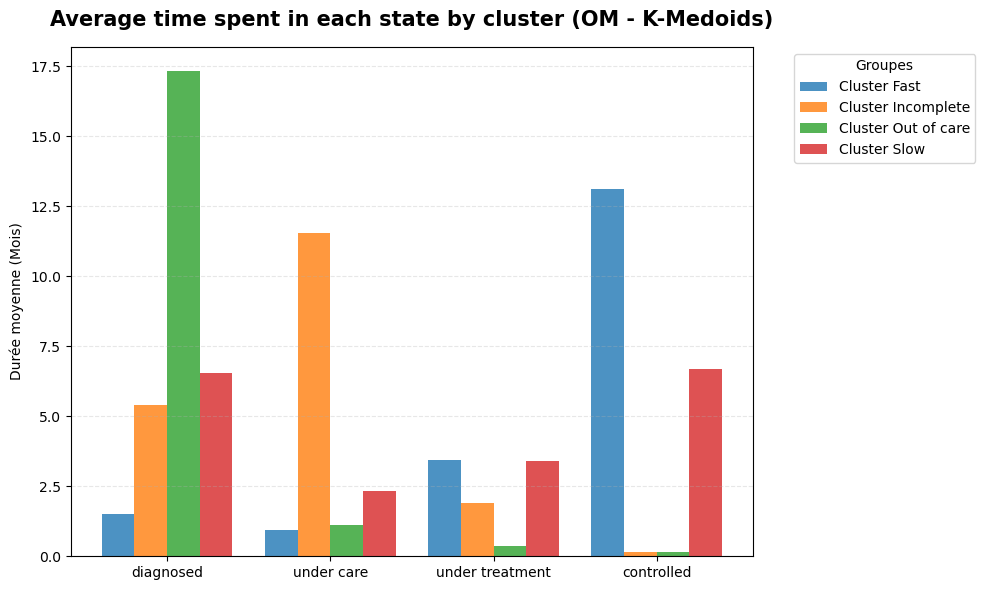

In [45]:
plot_mean_time(tca, clusters=kmedoids_labels_OM, title="Average time spent in each state by cluster (OM - K-Medoids)")

- The patients of the Fast cluster spend most of their time in the controlled state, they reach this state quickly and stay in it. 
- The patients in the Incomplete cluster are mostly diagnosed or under care, but not a lot are ubder treatment. 
- The Out of care cluster is characterized by a majority of patients that are only diagnosed, and don't get treated. 
- The patients of the Slow cluster spend time in all states, mostly the diagnosed and controlled state.

## 5.3. Medoid Trajectories
We can also introduce the equivalent of Traminer’s `seqrep` function, which extracts from each cluster the trajectory of a patient who is the “best” medoid and calculates the percentage of patients in the cluster who have a similar trajectory. We will use this `extract_rep_seq` function to compare our clusters with each other, this time using actual trajectories ($\neq$ modal trajectories), and this also allows us to verify that our patients in each cluster are sufficiently close to their medoids.

The choice of `coverage_threshold` depends on the cost matrix; if a substitution costs 1, a value of 5, for example, means that a patient is considered to be represented by the medoid sequence if there is at most the equivalent of 5 months of difference/substitution between the patient and the medoid.

When the coverage threshold is set to 0,that is, when we are looking for cluster trajectories that are identical to that of the medoid, relative to the OM distance,we observe that cluster 1 in HAC and cluster 2 in K-medoids are fairly well represented; however, we are seeking a coverage threshold that is not too large but maximizes the coverage rate for all clusters.

With these thresholds, the vast majority of patients are represented by the medoids of their clusters.

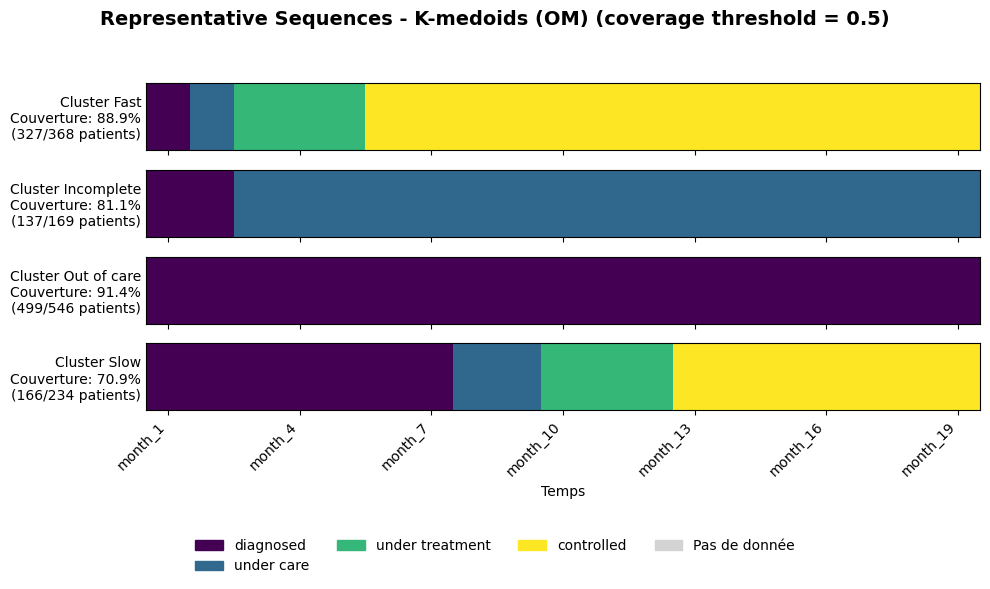

In [54]:
seuil_kmed = 0.5

res = extract_coverage_kmedoids(
    df_sequences=df_seq, 
    distance_matrix=distance_matrix_OM, 
    cluster_labels=kmedoids_labels_OM, 
    medoids_indices=medoid_indices_OM,
    coverage_threshold=seuil_kmed
)

plot_representative_sequences(tca, res, title=f"Representative Sequences - K-medoids (OM) (coverage threshold = {seuil_kmed})")

## 5.4. SeqTree

This method cross-references patient profiles (age, sex, etc.) with their time series data. It takes the covariates as input and identifies which variable best separates patients into groups with similar care pathways.

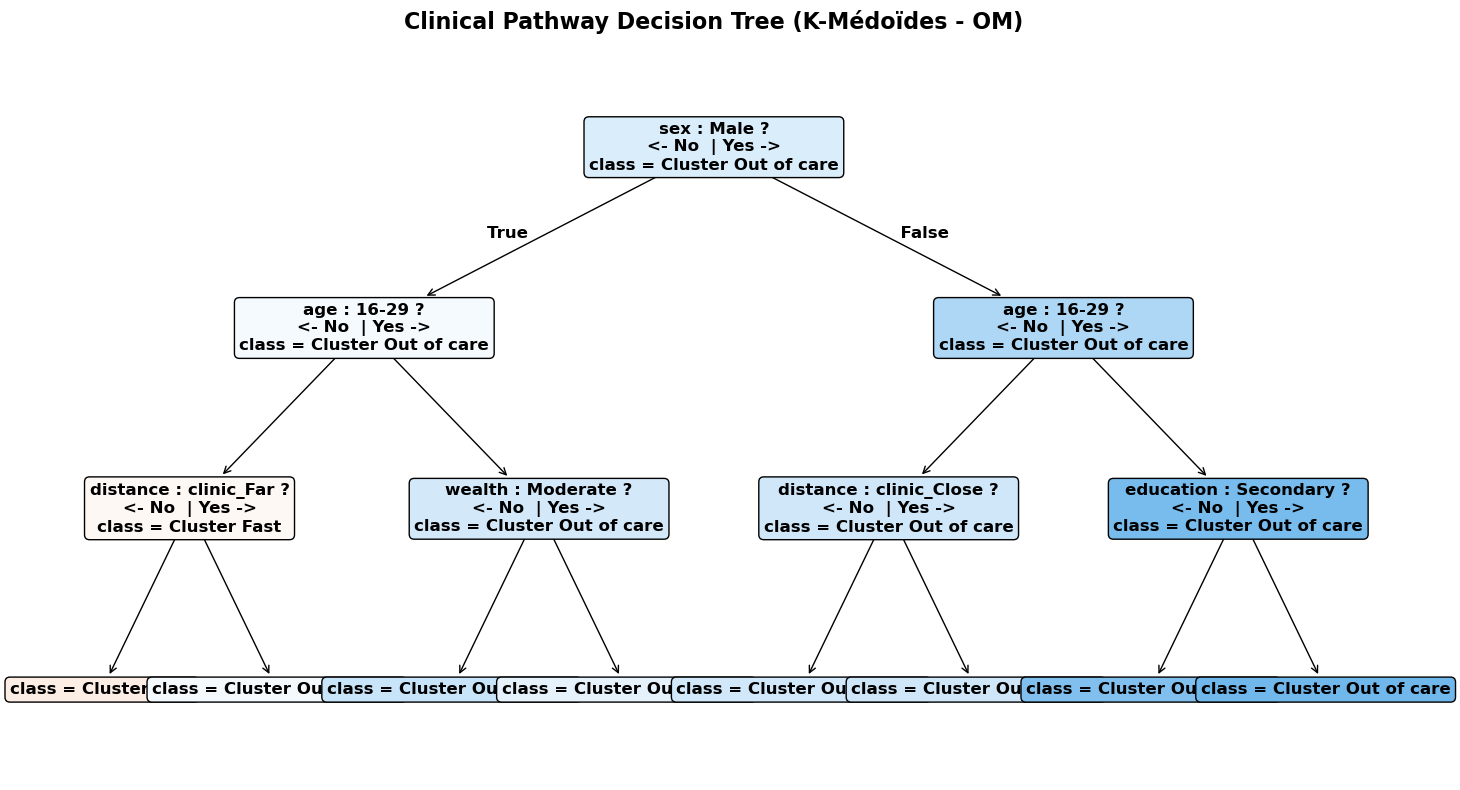

In [55]:
arbre_kmed = plot_trajectory_decision_tree(
    df_clinical=col_stats, 
    cluster_labels=kmedoids_labels_OM,
    max_depth=3,
    variables_label=label_var,
    titre="Clinical Pathway Decision Tree (K-Médoïdes - OM)"
)

## 5.5. Analysis of the Time to Controlled Infection (S)
We can visualize how quickly patients in each cluster reach state S. For each month, what percentage of patients in each cluster has reached state S?

To do this, we use the `lifelines` library.

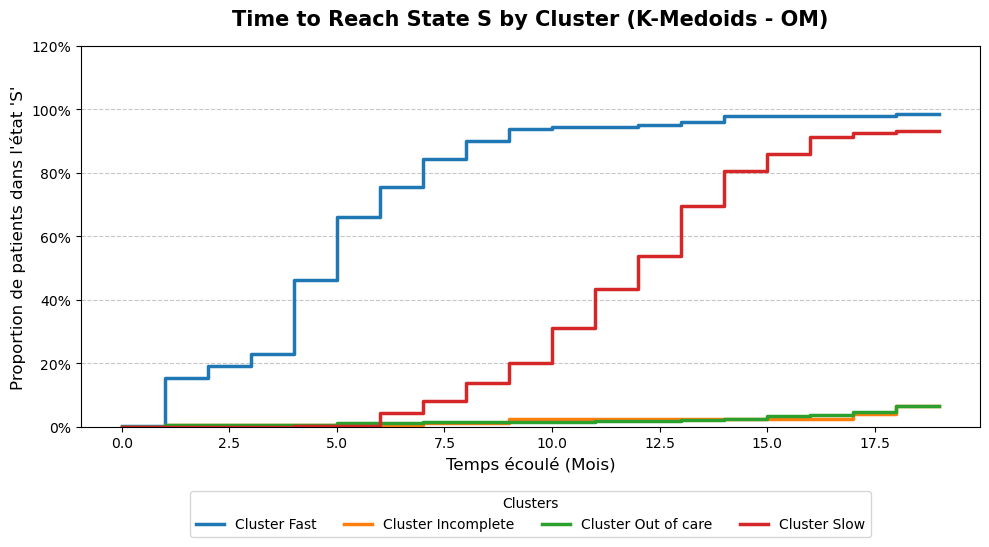

In [56]:
df_seq = tca.data.drop(columns=[tca.index_col])

plot_time_to_event(
    df_sequences=df_seq, 
    cluster_labels=kmedoids_labels_OM, 
    target_state='S',
    titre=f"Time to Reach State S by Cluster (K-Medoids - OM)"
)

* The majority of patients in clusters Out of care and Incomplete never reach the “controlled infection” state.
* Almost 100% of patients in cluster Slow are in the S state; it slowly reach the controlled state arounf 14 months.
* For cluster Fast, the percentage of patients in the controlled infection state approaches 100% very quickly.

## 5.6. Projecting Variables onto Clusters

This function allows you to visualize, for each variable, the distribution of patients across each cluster.

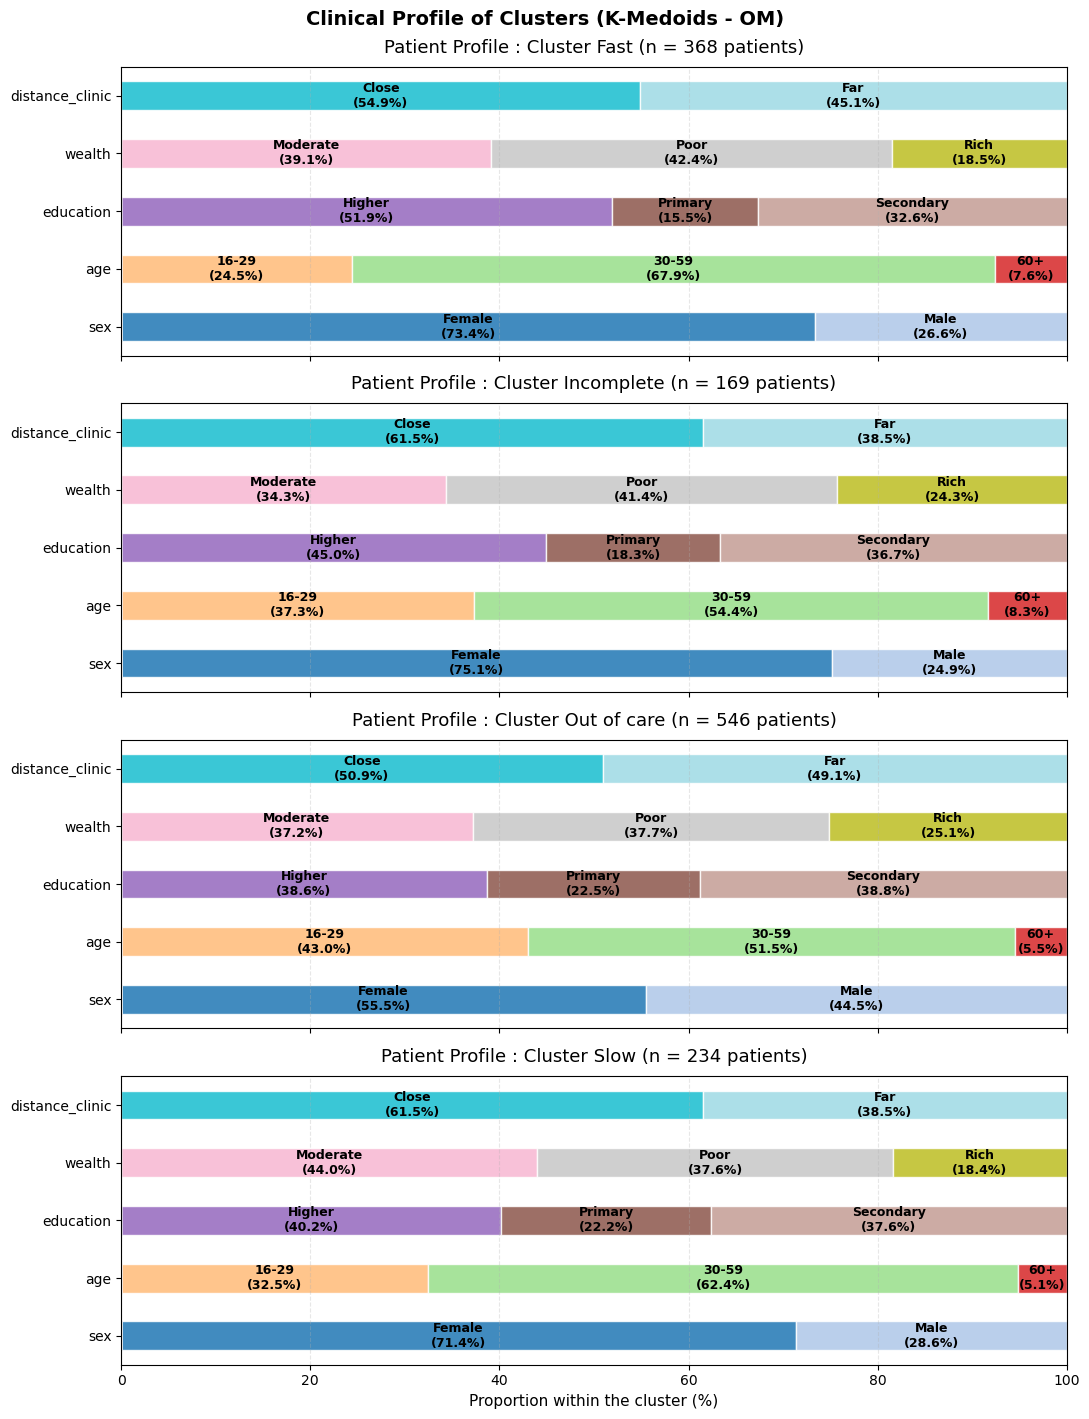

In [57]:
plot_cluster_profiles(
    df_clinical=col_stats, 
    cluster_labels=kmedoids_labels_OM, variables_label=label_var, titre="Clinical Profile of Clusters (K-Medoids - OM)"
)

* A majority of women in clusters Slow, Fast and Incomplete / Almost equal proportion of men and women in cluster Out of care.
* Few seniors in any of the clusters / a majority of adults in all clusters / more 16-29 in cluster Out of care.
* Average educational level is common in all clusters / few with primary education in cluster Fast / Majority of Higher education in cluster Fast.
* Moslty Moderate and Poor in all clusters, fewer riches..
* A majority of patients close to the clinic in cluster Incomplete and Slow.

## 5.7. Analysis of the Most Frequent Transitions
 This analysis identifies the transitions from one state to another that most strongly separate the clusters. This allows us to characterize the clusters based on the state changes that patients experience most frequently.

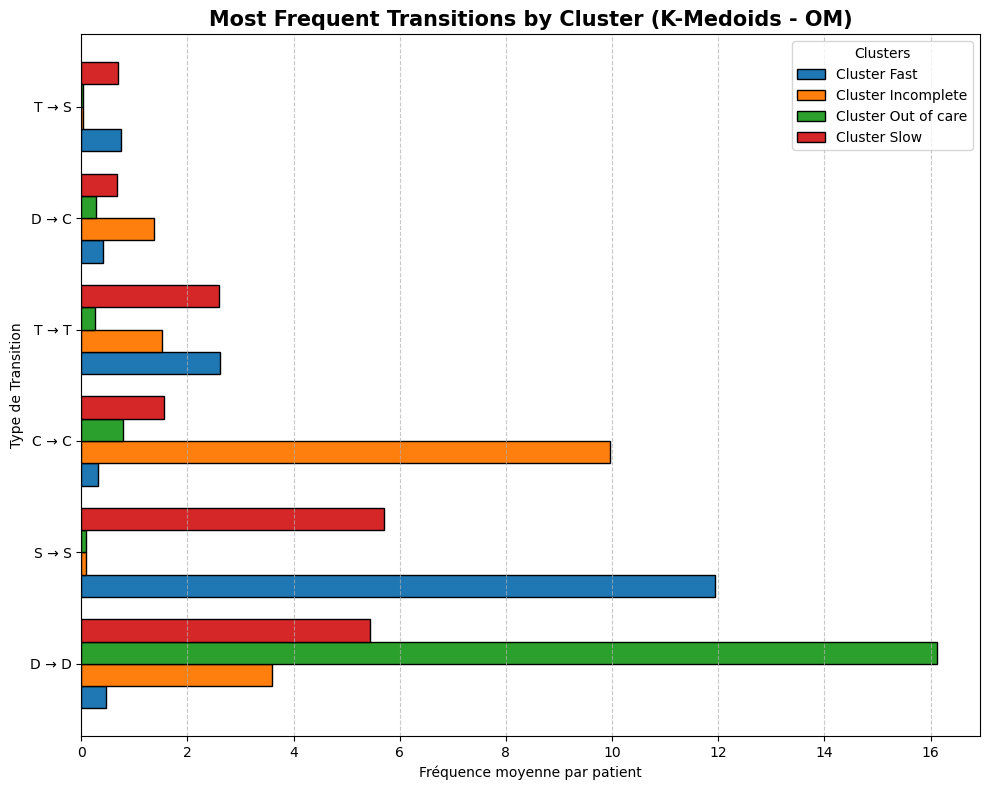

In [58]:
plot_frequent_transitions(tca, kmedoids_labels_OM, n_top=6, titre="Most Frequent Transitions by Cluster (K-Medoids - OM)")

* For cluster Fast, we remain in state S.
* For cluster Incomplete, the most common transition is C->C.
* For cluster Out of care, the D->D transition is the most common.
* For cluster Slow, the most common transitions are S->S, D->D.

## 5.8. The Most Distant Trajectories

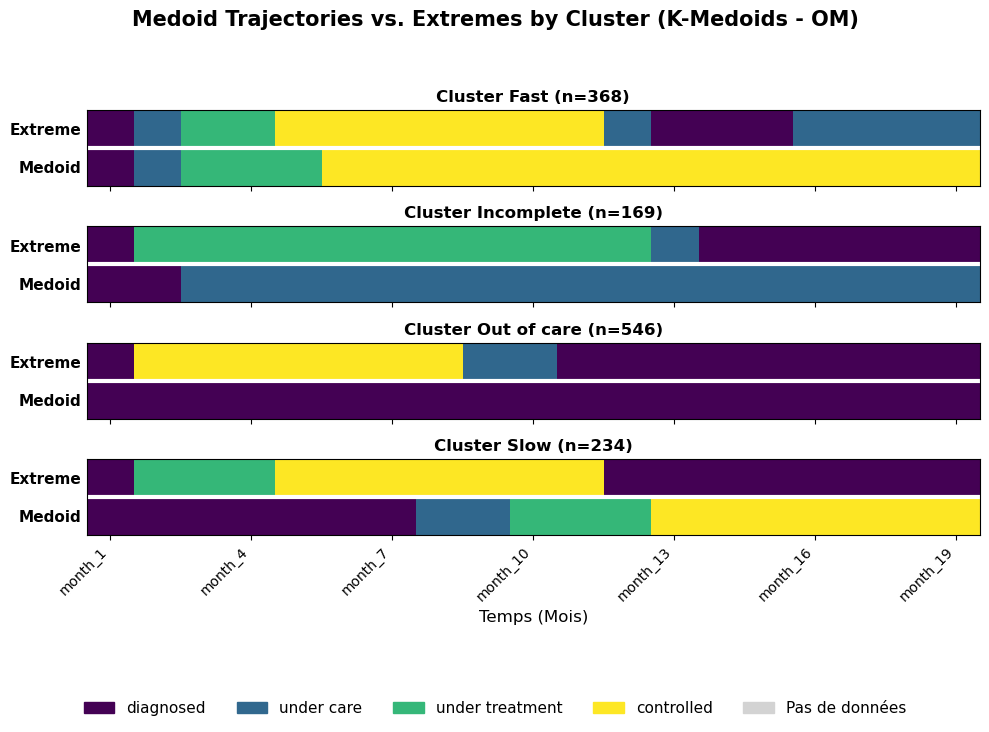

In [59]:
plot_extreme_trajectories(tca, clusters=kmedoids_labels_OM, 
                              distance_matrix=distance_matrix_OM,
                              title="Medoid Trajectories vs. Extremes by Cluster (K-Medoids - OM)")

## 5.9. Summary of Clusters

In [60]:
print("K-medoids (OM) :")
rep2 = summarize_clusters(tca=tca, clusters=kmedoids_labels_OM)

K-medoids (OM) :
SUMMARY OF CLUSTERS

CLUSTER Fast : 'S-DOMINANT'
   • Size       : 368 patients (27.9% of patients)
   • Frequent state     : 'S' (mean duration : 13.1)
   • Frequent transition   : S → S, T → T

CLUSTER Incomplete : 'C-DOMINANT'
   • Size       : 169 patients (12.8% of patients)
   • Frequent state     : 'C' (mean duration : 11.6)
   • Frequent transition   : C → C, D → D

CLUSTER Out of care : 'D-DOMINANT'
   • Size       : 546 patients (41.5% of patients)
   • Frequent state     : 'D' (mean duration : 17.3)
   • Frequent transition   : D → D, C → C

CLUSTER Slow : 'S-DOMINANT'
   • Size       : 234 patients (17.8% of patients)
   • Frequent state     : 'S' (mean duration : 6.7)
   • Frequent transition   : S → S, D → D



## 5.10. Patient Representation in Clusters

The following function generates a heatmap of the differences. It allows you to visualize the “signature” of each cluster by highlighting which characteristics are overrepresented or underrepresented in that cluster compared to the overall population.

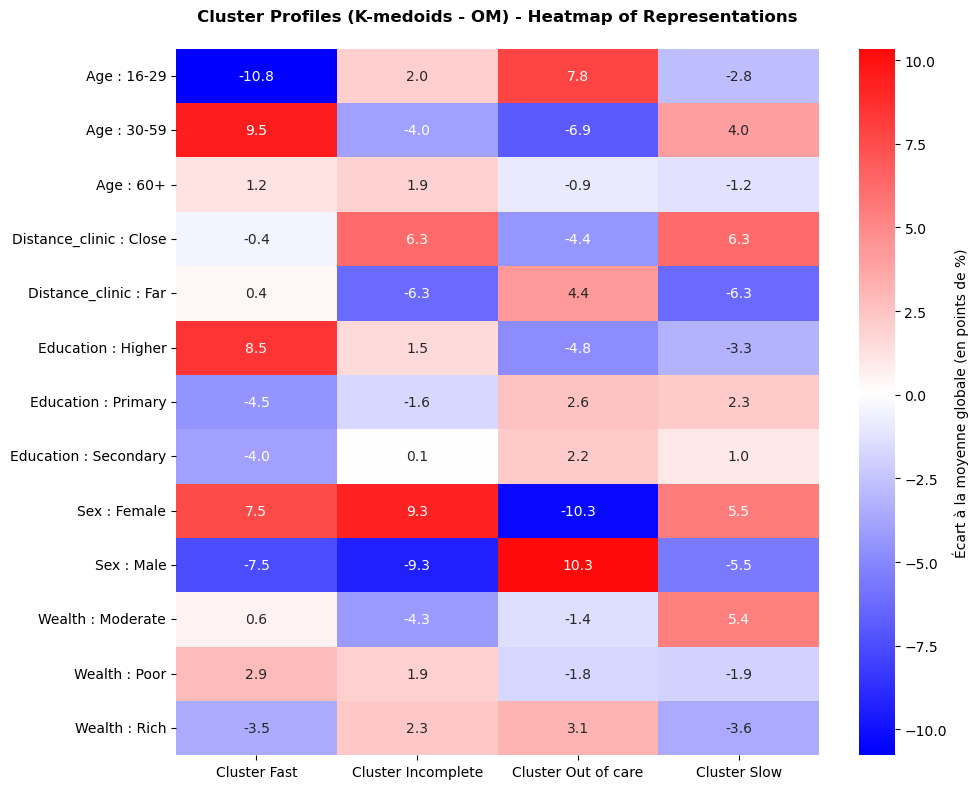

In [61]:
profil_clusters_heatmap(col_stats, kmedoids_labels_OM, label_var, titre="Cluster Profiles (K-medoids - OM) - Heatmap of Representations")

* Cluster Fast:
    * Women, middle aged adults, with a lower income, and those with a higher level are over-represented in this cluster compared to the global average.
    * Young adults, patients with a primary and secondary degree, and those with a high income are under-represented in this cluster compared to the global average.

* Cluster Incomplete:
    * Women close to the clinic are over-represented in this cluster compared to the global average.
    * Adults and patients with a high education level are under-represented in this cluster compared to the global average.

* Cluster Out of care:
    * Men, young adults, patients living far from the clinic, those with a primary and secondary degree, and those with higher income are over-represented in this cluster compared to the global average.
    * Middle aged patients, those with a high education level, and those with a low to moderate income are under-represented in this cluster compared to the global average.

* Cluster Slow:
    * Women, middle aged adults, patients living close to the clinic, those with a primary and secondary degree, and those with a moderate income are over-represented in this cluster compared to the global average.
    * Young and senior patients, those with a high education level, and those with a low and high income are under-represented in this cluster compared to the global average.
